This is the same project. I transferred the code to a Jupyter Notebook to display the visuals.

In [ ]:
# Load libraries
library(readxl)
library(tidyr)
library(summarytools)
library(ggplot2)
library(tidyverse)
library(directlabels)
library(scales)
library(rmarkdown)
library(ggrepel)
library(ggforce)
library(maps)
library(rnaturalearth)
library(rnaturalearthdata)
library(sf)
library(gridExtra)

In [ ]:
#### Preparing the downloaded files from GBD for use ####

# GBD download filters
## Cause of Death
## Death, DALY, Prevalence, Incidence
## Number, Percent, Rate
## HIV/AIDS, Syphilis, Chlamydial Infection, Gonococcal Infection, Trichomoniasis, Genital Herpes, Other sexually transmitter diseases
## [EU-28]
## All ages, 0-14, 15-49, 50-74, 75+
## Male, Female, Both
## [year 2000-2021]


# Due to download restraints in large files from the GBD, we had to download multiple smaller files separately and join them together
# This section prepares the main DF that will be used for the main analysis

# Set working directory to where all the files downloaded from the GBD Database are
setwd("DATA/Coding Project/Second attempt")


# Merge all the downloaded GBD files into a single data frame "STI"
GBD_RAW <- 
  do.call(rbind,
          lapply(list.files("/run/media/bruce/WD/PhD/DATA/Coding Project/Second attempt/Unzipped Files/"), read.csv))


# Some of the files downloaded includes one extra variable that was not supposed to be included. 
# Error cleanup: Remove lines with "393" (STIs without HIV) on column "cause"

# create a new DF without the lines that have the wrong code
STI_temp <- filter(GBD_RAW, cause !="393") 

# confirm presence/absence of the 393 code in old/new DF
table(GBD_RAW$cause) 
table(STI_temp$cause) 

# Export STI into CSV, into main Working Directory
write.csv(STI_temp, "/run/media/bruce/WD/PhD/DATA/Coding Project/Second attempt/Unzipped Files/GBD_STI.csv", row.names = FALSE)

In [4]:
# Set working directory to main directory
setwd("/run/media/bruce/WD/PhD/DATA/Coding Project/Second attempt/")

# load required DFs
GBD_STI <- read.csv("GBD_STI.csv")
GBD_KEY <- read.csv("IHME_GBD_2021_CODEBOOK_Y2024M05D16.CSV")

# make a copy of the main DF
STI <- GBD_STI

# Swap IDs for their Full Names in STI
STI$measure  <- GBD_KEY$measure_name  [match(STI$measure,  GBD_KEY$measure_id)]
STI$location <- GBD_KEY$location_name [match(STI$location, GBD_KEY$location_id)]
STI$sex      <- GBD_KEY$sex_label     [match(STI$sex,      GBD_KEY$sex_id)]
STI$age      <- GBD_KEY$age_group_name[match(STI$age,      GBD_KEY$age_group_id)]
STI$cause    <- GBD_KEY$cause_name    [match(STI$cause,    GBD_KEY$cause_id)]
STI$metric   <- GBD_KEY$metric_name   [match(STI$metric,   GBD_KEY$metric_id)]

# Change data type
STI$measure  <- as.factor(STI$measure)
STI$location <- as.factor(STI$location)
STI$sex      <- as.factor(STI$sex)
STI$age      <- as.factor(STI$age)
STI$cause    <- as.factor(STI$cause)
STI$metric   <- as.factor(STI$metric)

# confirm changes
str(STI)

# verify all data present after changing existing values. Failed matches return "NA". Both tables should return the same number of NAs
sapply(GBD_STI, function(x) sum(is.na(x)))
sapply(STI, function(x) sum(is.na(x)))

'data.frame':	702240 obs. of  10 variables:
 $ measure : Factor w/ 4 levels "DALYs (Disability-Adjusted Life Years)",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ location: Factor w/ 28 levels "Austria","Belgium",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ sex     : Factor w/ 3 levels "Both","Female",..: 3 2 1 3 2 1 3 2 1 3 ...
 $ age     : Factor w/ 5 levels "0 to 14","15-49 years",..: 5 5 5 5 5 5 5 5 5 2 ...
 $ cause   : Factor w/ 7 levels "Chlamydial infection",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ metric  : Factor w/ 3 levels "Number","Percent",..: 1 1 1 2 2 2 3 3 3 1 ...
 $ year    : int  2019 2019 2019 2019 2019 2019 2019 2019 2019 2019 ...
 $ val     : num  4.39e+01 1.35e+01 5.75e+01 6.86e-04 2.31e-04 ...
 $ upper   : num  4.40e+01 1.35e+01 5.75e+01 7.12e-04 2.39e-04 ...
 $ lower   : num  4.39e+01 1.35e+01 5.74e+01 6.60e-04 2.23e-04 ...


measure location      sex      age    cause   metric     year      val 
       0        0        0        0        0        0        0        0 
   upper    lower 
       0        0

measure location      sex      age    cause   metric     year      val 
       0        0        0        0        0        0        0        0 
   upper    lower 
       0        0

Now we will look at descriptive statistics

In [ ]:
dfSummary(STI)               # we chose this one for its more detailed info


,No,Variable,Stats / Values,Freqs (% of Valid),Graph,text.graph,Valid,Missing
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,measure\ [factor],1\. DALYs (Disability-Adjuste\ 2\. Deaths\ 3\. Incidence\ 4\. Prevalence,\194040 (27.6%)\ \138600 (19.7%)\ \184800 (26.3%)\ \184800 (26.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAADYAAABmCAQAAAAqwqqhAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwWBSItww8AAAClSURBVGje7dhBDkAwFIThVpzOCTghJ+j12FYRTb1WjH92TcSXmC4m/OrapWtoCWN9fJgrFDj5C8y5wZgKu5NuZ2BgYGBgYApYMgtC2Vsy4+ONU2OwRnvnL50tD77j6O+fMdqNeRdLtzMwMDAwMDAFjN1oEl3MbKSeJR2uFX9uHm+2bmdgYGBgYGAKGCPVJOzGgrAbwcDAwMDAvoW9txtrR7ezptgGTt4Xs6fokBEAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6MjI6MDUrMDA6MDADK8IKAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjIyOjA1KzAwOjAwcnZ6tgAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjoyMjowNSswMDowMCVjW2kAAAAASUVORK5CYII="">",IIIII \ III \ IIIII \ IIIII,702240\ (100.0%),0\ (0.0%)
2,2,location\ [factor],1\. Austria\ 2\. Belgium\ 3\. Bulgaria\ 4\. Croatia\ 5\. Cyprus\ 6\. Czechia\ 7\. Denmark\ 8\. Estonia\ 9\. Finland\ 10\. France\ [ 18 others ],\ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \ 25080 ( 3.6%)\ \451440 (64.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG0AAAEKCAQAAACydxOLAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwWBSItww8AAAG3SURBVHja7djBaQJhFEbRTLA6K0gqNBXYntkk8I8wmyAM5+WejYibufAU/LbH21TvZz9AaaWtLuub2/LF+9jOfrS/WB/6sv/o+vN6P/sZX2DwQZYmKk1Umqg0UWmi0kSliUoTPf3LnvDv+te27pD+JrluI4MPsjTR7mfki98hD9PaIRGliUoTlSYqTVSaqDRRaaLSRO2QinZIXWOdaPBBliYqTVSaqDRRaaLSRKWJShMNTmuHVLRD6tohRYMPsjRRaaLSRKWJShOVJipNVJpocFo7pKIdUtcOKRp8kKWJShOVJipNVJqoNFFpotJEjXWKxjrd4LR2SNHggyxNVJqoNFFpotJEpYlKE5UmaodUtEPqBqe1Q4oGH2RpotJEpYlKE5UmKk1Umqg0UTukoh1S11gnGnyQpYlKE5UmKk1Umqg0UWmi0kSD09ohFe2QunZI0eCDLE1Umqg0UWmi0kSliUoTlSYanNYOqWiH1LVDigYfZGmi0kSliUoTlSYqTVSaqDRRY52isU43OO1whzR9Ll+2gx3StP99H3yQpYlKE5UmKk1Umqg0UWmi0kT/ZYecZfBBlib6Bu9UQRIB2CZkAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjIyOjA1KzAwOjAwAyvCCgAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjoyMjowNSswMDowMHJ2erYAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6MjI6MDUrMDA6MDAlY1tpAAAAAElFTkSuQmCC"">",\ \ \ \ \ \ \ \ \ \ IIIIIIIIIIII,702240\ (100.0%),0\ (0.0%)
3,3,sex\ [factor],1\. Both\ 2\. Female\ 3\. Male,\240240 (34.2%)\ \240240 (34.2%)\ \221760 (31.6%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAEAAAABOCAQAAAA6atglAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwWBSItww8AAACUSURBVGje7de7DcMwDAVAKfB0mcCZMJnA6zmt/EkTA3wujp1USAdQAvj62rL1CN8P0KZx8S56EK/+A9Das+D6ZbOKtwAAAAAAAAAAIA7YjWTLf6dcqD7OoVUhZZhJ8y0A2DzCj2ASKAAAAAAAAAAAuSDeAoDSXDD3415hLjj/YfEWAAAAAAAAAADEAfcKJomKtwDgC23nEcoWBDRXAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjIyOjA1KzAwOjAwAyvCCgAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjoyMjowNSswMDowMHJ2erYAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6MjI6MDUrMDA6MDAlY1tpAAAAAElFTkSuQmCC"">",IIIIII \ IIIIII \ IIIIII,702240\ (100.0%),0\ (0.0%)
4,4,age\ [factor],1\. 0 to 14\ 2\. 15-49 years\ 3\. 50 to 74 years\ 4\. 75 plus\ 5\. All Ages,\140448 (20.0%)\ \140448 (20.0%)\ \140448 (20.0%)\ \140448 (20.0%)\ \140448 (20.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAACsAAAB9CAQAAACRg1KhAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwWBSItww8AAACHSURBVGje7daxDYAwDEXBBDEdGzAhTJD1oI1ANCBHWLp0aa74jV89SsSbQtRk7Nx/tk9Dr/WBLWV5jbYRI2CxWCw2NXs5Ou2dcnu1v4rfUqS7kJm33XUCFovFYvOxOiGO1Ql

* The above output is much cleaner in RStudio. I am still trying to troubleshoot the output specific to Jupyter Notebook

In [24]:
# Code edited for display in Jupyter Notebook:

# Generate report to current directory
dlookr::diagnose_web_report(STI, 
                           output_dir = getwd(), 
                           output_file = "report.html",
                           browse = FALSE)  # Prevent auto-open

# Display inline
IRdisplay::display_html("<iframe src='report.html' width='100%' height='800'></iframe>")



processing file: diagnosis_temp.Rmd



1/67                         
2/67 [setup]                 
3/67                         
4/67 [load_packages]         
5/67                         
6/67 [get-parameters]        
7/67                         
8/67 [unnamed-chunk-1]       
9/67                         
10/67 [diagose]               
11/67                         
12/67 [create-overview]       
13/67                         
14/67 [overview]              
15/67                         
16/67 [overview-datastructure]
17/67                         
18/67 [overview-pre]          
19/67                         
20/67 [overview-warnings]     
21/67                         
22/67 [warnings_summary]      
23/67                         
24/67 [warnings]              
25/67                         
26/67 [overview-variables]    
27/67                         
28/67 [variables]             
29/67                         
30/67 [missing]               
31/67                         
32/67 [missing-list]          
33/67            

output file: diagnosis_temp.knit.md




/usr/bin/pandoc +RTS -K512m -RTS diagnosis_temp.knit.md --to html4 --from markdown+autolink_bare_uris+tex_math_single_backslash --output pandoc1cc97d2faaba6e.html --lua-filter /home/bruce/R/x86_64-pc-linux-gnu-library/4.5/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /home/bruce/R/x86_64-pc-linux-gnu-library/4.5/rmarkdown/rmarkdown/lua/latex-div.lua --lua-filter /home/bruce/R/x86_64-pc-linux-gnu-library/4.5/rmarkdown/rmarkdown/lua/table-classes.lua --embed-resources --standalone --variable bs3=TRUE --section-divs --template /home/bruce/R/x86_64-pc-linux-gnu-library/4.5/rmarkdown/rmd/h/default.html --no-highlight --variable highlightjs=1 --variable theme=bootstrap --css /home/bruce/R/x86_64-pc-linux-gnu-library/4.5/dlookr/resources/dlookr-bootstrap.css --mathjax --variable 'mathjax-url=https://mathjax.rstudio.com/latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML' --include-in-header /tmp/Rtmpkuh1R9/rmarkdown-str1cc97d1a821784.html --variable code_folding=show --variable code_menu=1 --


Output created: report.html



In [25]:
## Finding outliers
# First diagnosis
diagnose_outlier(STI)

# But 143k outliers in 702k were too much, so we investigated further
X_POR_DEA_HIV_NUM_ALA <- filter(STI, measure == "Deaths" & location =="Portugal" & cause =="HIV/AIDS" & metric =="Number" & age =="All Ages")
diagnose_outlier(X_POR_DEA_HIV_NUM_ALA)

X_POR_PRE_HIV_NUM_ALA <- filter(STI, measure == "Prevalence" & location =="Portugal" & cause =="HIV/AIDS" & metric =="Number" & age =="All Ages")
diagnose_outlier(X_POR_PRE_HIV_NUM_ALA)

variables,outliers_cnt,outliers_ratio,outliers_mean,with_mean,without_mean
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
year,0,0.00000,NaN,2010.500,2010.500000
val,143394,20.41951,56845.99,11614.506,8.583731
upper,142391,20.27669,71590.21,14526.614,13.159149
lower,146003,20.79104,44624.11,9281.756,4.974159


variables,outliers_cnt,outliers_ratio,outliers_mean,with_mean,without_mean
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
year,0,0,NaN,2010.5000,2010.5000
val,0,0,NaN,414.1476,414.1476
upper,0,0,NaN,415.3305,415.3305
lower,0,0,NaN,412.9522,412.9522


variables,outliers_cnt,outliers_ratio,outliers_mean,with_mean,without_mean
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
year,0,0,NaN,2010.50,2010.50
val,0,0,NaN,27661.81,27661.81
upper,0,0,NaN,29699.01,29699.01
lower,0,0,NaN,25599.28,25599.28


We concluded that the outliers were not true outliers, so we kept them in.

In [26]:
## Missing values
# Diagnosis
sapply(STI, function(x) sum(is.na(x)))

measure location      sex      age    cause   metric     year      val 
       0        0        0        0        0        0        0        0 
   upper    lower 
       0        0

We concluded that there are no NA values in the data.

We then explored the data to determine if "unrealistic" values were entered, such as percentages > 1.0 or event rates > 100,000 since rates are measured in "events per 100k population." 

In [27]:
## Unreliable data
# Rates are described as "events per 100k population". There should not be any rates >100000
base::summary(STI %>% filter(metric == "Rate" & val > 100000))

# Percentages must be ≤1
base::summary(STI %>% filter(metric == "Percent" & val > 1))

# There should not be any 0s in the data.
base::summary(STI %>% filter(val == "0"))

# make a DF with only the "0"
STI_0 <- STI %>% filter(val == "0")

# Check percentage of "0" 
STI_0_sum = summarytools::descr(STI_0)
STI_sum   = summarytools::descr(STI)
STI_0_sum[14,]/STI_sum[14,]

# first diagnosis of "0"
dfSummary(STI_0)
table(STI_0$measure, STI_0$location)
table(STI_0$sex,     STI_0$age)
table(STI_0$cause,   STI_0$metric)
dfSummary(STI_0 %>% filter(cause == "Chlamydial infection"))
# there is no data on Male + Deaths + Chlamydial infection

# second diagnosis of "0"
STI_0a <- STI_0 %>% filter(cause != "Chlamydial infection")
dfSummary(STI_0a)
table(STI_0a$measure, STI_0a$location)
table(STI_0a$sex,     STI_0a$age)
table(STI_0a$cause,   STI_0a$metric)
dfSummary(STI_0 %>% filter(measure == "Incidence"))
dfSummary(STI_0 %>% filter(measure == "Incidence" & cause == "Syphilis")) 
# there is no data on incidence of Syphilis on ages 75+ 

dfSummary(STI_0 %>% filter(measure == "Incidence" & cause == "Other sexually transmitted infections")) 
# there is no data on incidence of "Other sexually transmitted infections"

# third diagnosis of "0"
STI_0b <- STI_0a %>% filter(measure != "Incidence")
dfSummary(STI_0b)
# there is no data on prevalence of "Other sexually transmitted infections" on 75+

                                   measure      location     sex   
 DALYs (Disability-Adjusted Life Years):0   Austria :0   Both  :0  
 Deaths                                :0   Belgium :0   Female:0  
 Incidence                             :0   Bulgaria:0   Male  :0  
 Prevalence                            :0   Croatia :0             
                                            Cyprus  :0             
                                            Czechia :0             
                                            (Other) :0             
             age                                      cause       metric 
 0 to 14       :0   Chlamydial infection                 :0   Number :0  
 15-49 years   :0   Genital herpes                       :0   Percent:0  
 50 to 74 years:0   Gonococcal infection                 :0   Rate   :0  
 75 plus       :0   HIV/AIDS                             :0              
 All Ages      :0   Other sexually transmitted infections:0              
            

                                   measure      location     sex   
 DALYs (Disability-Adjusted Life Years):0   Austria :0   Both  :0  
 Deaths                                :0   Belgium :0   Female:0  
 Incidence                             :0   Bulgaria:0   Male  :0  
 Prevalence                            :0   Croatia :0             
                                            Cyprus  :0             
                                            Czechia :0             
                                            (Other) :0             
             age                                      cause       metric 
 0 to 14       :0   Chlamydial infection                 :0   Number :0  
 15-49 years   :0   Genital herpes                       :0   Percent:0  
 50 to 74 years:0   Gonococcal infection                 :0   Rate   :0  
 75 plus       :0   HIV/AIDS                             :0              
 All Ages      :0   Other sexually transmitted infections:0              
            

                                   measure          location         sex       
 DALYs (Disability-Adjusted Life Years):    0   Austria : 1320   Both  :12936  
 Deaths                                : 9240   Belgium : 1320   Female:12936  
 Incidence                             :24024   Bulgaria: 1320   Male  :11088  
 Prevalence                            : 3696   Croatia : 1320                 
                                                Cyprus  : 1320                 
                                                Czechia : 1320                 
                                                (Other) :29040                 
             age                                          cause      
 0 to 14       : 5544   Chlamydial infection                 : 9240  
 15-49 years   : 5544   Genital herpes                       :    0  
 50 to 74 years: 5544   Gonococcal infection                 :    0  
 75 plus       :14784   HIV/AIDS                             :    0  
 All Ages 

lower      upper        val       year 
0.05263158 0.05263158 0.05263158 0.05263158

,No,Variable,Stats / Values,Freqs (% of Valid),Graph,text.graph,Valid,Missing
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,measure\ [factor],1\. DALYs (Disability-Adjuste\ 2\. Deaths\ 3\. Incidence\ 4\. Prevalence,\ 0 ( 0.0%)\ \ 9240 (25.0%)\ \24024 (65.0%)\ \ 3696 (10.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG4AAABmCAQAAACAAWwdAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEeIypRcAAADzSURBVHja7dpBDoIwAAXR1nA6T6An1BN4PdwWSUzUkna+83ZsDBMLix/qWnKdRt+AccbtLe3Fbb3U0Tf0qzYg+p8zjso4KuOojKMyjso4KuOojKMyjio6rrajbMJA60CUYLNb3jueyxkW0GV7ee70s4/RXaWU8GNpHJVxVMZRGUdlHJVxVMZRGUcVHfcyM8wxD/TibkllHNVho+wo1+ahO2iUHWX7to8+lsZRGUdlHJVxVMZRGUdlHJVxVNFxjrIkjrIJPtotZ/hA9Ou497sl72UTfSyNozKOyjgq46iMozKOyjgq46ii4/5nt0wTfSyNo3oCtHQV+oK3OnIAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTcrMDA6MDBIS+IJAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE3KzAwOjAwORZatQAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxNyswMDowMG4De2oAAAAASUVORK5CYII="">",\ IIIII \ IIIIIIIIIIIII \ II,36960\ (100.0%),0\ (0.0%)
2,2,location\ [factor],1\. Austria\ 2\. Belgium\ 3\. Bulgaria\ 4\. Croatia\ 5\. Cyprus\ 6\. Czechia\ 7\. Denmark\ 8\. Estonia\ 9\. Finland\ 10\. France\ [ 18 others ],\ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \ 1320 ( 3.6%)\ \23760 (64.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG0AAAEKCAQAAACydxOLAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEeIypRcAAAG3SURBVHja7djBaQJhFEbRTLA6K0gqNBXYntkk8I8wmyAM5+WejYibufAU/LbH21TvZz9AaaWtLuub2/LF+9jOfrS/WB/6sv/o+vN6P/sZX2DwQZYmKk1Umqg0UWmi0kSliUoTPf3LnvDv+te27pD+JrluI4MPsjTR7mfki98hD9PaIRGliUoTlSYqTVSaqDRRaaLSRO2QinZIXWOdaPBBliYqTVSaqDRRaaLSRKWJShMNTmuHVLRD6tohRYMPsjRRaaLSRKWJShOVJipNVJpocFo7pKIdUtcOKRp8kKWJShOVJipNVJqoNFFpotJEjXWKxjrd4LR2SNHggyxNVJqoNFFpotJEpYlKE5UmaodUtEPqBqe1Q4oGH2RpotJEpYlKE5UmKk1Umqg0UTukoh1S11gnGnyQpYlKE5UmKk1Umqg0UWmi0kSD09ohFe2QunZI0eCDLE1Umqg0UWmi0kSliUoTlSYanNYOqWiH1LVDigYfZGmi0kSliUoTlSYqTVSaqDRRY52isU43OO1whzR9Ll+2gx3StP99H3yQpYlKE5UmKk1Umqg0UWmi0kT/ZYecZfBBlib6Bu9UQRIB2CZkAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjQ5OjE3KzAwOjAwSEviCQAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjo0OToxNyswMDowMDkWWrUAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6NDk6MTcrMDA6MDBuA3tqAAAAAElFTkSuQmCC"">",\ \ \ \ \ \ \ \ \ \ IIIIIIIIIIII,36960\ (100.0%),0\ (0.0%)
3,3,sex\ [factor],1\. Both\ 2\. Female\ 3\. Male,\12936 (35.0%)\ \12936 (35.0%)\ \11088 (30.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAEEAAABOCAQAAADVqLMbAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEeIypRcAAACcSURBVGje7ddBCoAwDETRiXg6T6An1BP0erpwUwtVUEgi/NkVQR6khYztis4QDYBwZqwPq9vFWKxDkCYXQLmcEgwCAgQIECBAgADhB4RmcSvv/vIpVm+sfrWm2l4zDAKC1FzHjSoTFggQIECAAAEChKfQI6QUg4AgOfaI2XpfnHrE3UtLMAgIECBAgAABAoQfELJVmZgkGAQESToAf08RyuoGGrYAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTcrMDA6MDBIS+IJAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE3KzAwOjAwORZatQAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxNyswMDowMG4De2oAAAAASUVORK5CYII="">",IIIIIII \ IIIIIII \ IIIIII,36960\ (100.0%),0\ (0.0%)
4,4,age\ [factor],1\. 0 to 14\ 2\. 15-49 years\ 3\. 50 to 74 years\ 4\. 75 plus\ 5\. All Ages,\ 5544 (15.0%)\ \ 5544 (15.0%)\ \ 5544 (15.0%)\ \14784 (40.0%)\ \ 5544 (15.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAEkAAAB9CAQAAABEkYbsAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEeIypRcAAADqSURBVHja7dlRCoMwFETRpmR1XUG7Ql2B22t/X4TAU

...

,No,Variable,Stats / Values,Freqs (% of Valid),Graph,text.graph,Valid,Missing
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,measure\ [factor],1\. DALYs (Disability-Adjuste\ 2\. Deaths\ 3\. Incidence\ 4\. Prevalence,\ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \5544 (100.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKIAAABmCAQAAADigoIyAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAE4SURBVHja7dtBCoJQAEXRDFfXCmqFtQK3V1NtJHpBrHNmEoRcvk4eDu8Le12PvoFfIGJAxMA4v3i+78PRN3QW81BOYkDEgIgBEQMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDw3y8N+SvZ6iKiRhYRHx5njdxEgMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYsDtvZHeOiRgQMbD4aNx4v95j9lIclz/djr63k5gWVx7ngIgBEQMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIga95YNr2L3/OeL+R8T4mYsBH4wEnMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYEDEgYkDEgIiBwTa1n5MYEDEgYuADmB4R0IEdll8AAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDC+A5LgAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwz14qXAAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMJhLC4MAAAAASUVORK5CYII="">",\ \ IIIIIIIIIIIIIIIIIIII \,5544\ (100.0%),0\ (0.0%)
2,2,location\ [factor],1\. Austria\ 2\. Belgium\ 3\. Bulgaria\ 4\. Croatia\ 5\. Cyprus\ 6\. Czechia\ 7\. Denmark\ 8\. Estonia\ 9\. Finland\ 10\. France\ [ 18 others ],\ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \ 198 ( 3.6%)\ \3564 (64.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG0AAAEKCAQAAACydxOLAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAG3SURBVHja7djBaQJhFEbRTLA6K0gqNBXYntkk8I8wmyAM5+WejYibufAU/LbH21TvZz9AaaWtLuub2/LF+9jOfrS/WB/6sv/o+vN6P/sZX2DwQZYmKk1Umqg0UWmi0kSliUoTPf3LnvDv+te27pD+JrluI4MPsjTR7mfki98hD9PaIRGliUoTlSYqTVSaqDRRaaLSRO2QinZIXWOdaPBBliYqTVSaqDRRaaLSRKWJShMNTmuHVLRD6tohRYMPsjRRaaLSRKWJShOVJipNVJpocFo7pKIdUtcOKRp8kKWJShOVJipNVJqoNFFpotJEjXWKxjrd4LR2SNHggyxNVJqoNFFpotJEpYlKE5UmaodUtEPqBqe1Q4oGH2RpotJEpYlKE5UmKk1Umqg0UTukoh1S11gnGnyQpYlKE5UmKk1Umqg0UWmi0kSD09ohFe2QunZI0eCDLE1Umqg0UWmi0kSliUoTlSYanNYOqWiH1LVDigYfZGmi0kSliUoTlSYqTVSaqDRRY52isU43OO1whzR9Ll+2gx3StP99H3yQpYlKE5UmKk1Umqg0UWmi0kT/ZYecZfBBlib6Bu9UQRIB2CZkAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwvgOS4AAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMM9eKlwAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDCYSwuDAAAAAElFTkSuQmCC"">",\ \ \ \ \ \ \ \ \ \ IIIIIIIIIIII,5544\ (100.0%),0\ (0.0%)
3,3,sex\ [factor],1\. Both\ 2\. Female\ 3\. Male,\1848 (33.3%)\ \1848 (33.3%)\ \1848 (33.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAD8AAABOCAQAAAA9KAYwAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAACHSURBVGje7dexDcAgDERRHGW6bJAJwwSsl7QmUhokfBH+17nhSUBxtrsos0n15PzuhyvkI5z2wZdyTMdbN+V+e3h4eHh4ePj1+VfZamOnDMd8u4xZOVzTVF9+br77epU1IzTw8PDw8PDw6/P0fGFy8/R8YeDh4eHh4eHhJ+dPa0Z8cr+9mH8AZlURy0jxTXIAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDC+A5LgAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwz14qXAAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMJhLC4MAAAAASUVORK5CYII="">",IIIIII \ IIIIII \ IIIIII,5544\ (100.0%),0\ (0.0%)
4,4,age\ [factor],1\. 0 to 14\ 2\. 15-49 years\ 3\. 50 to 74 years\ 4\. 75 plus\ 5\. All Ages,\ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \5544 (100.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKIAAAB9CAQAAACLk3BqAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAFsSURBVHja7dzBCcJA

ERROR: Error in if (grepl("^get\\(", deparse(call[[.p$var]]))) {: the condition has length > 1


Warning message in parse_call(mc = match.call(), var_name = get_var_info, var_label = get_var_info, :
“metadata extraction terminated unexpectedly; inspect results carefully”


,No,Variable,Stats / Values,Freqs (% of Valid),Graph,text.graph,Valid,Missing
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,measure\ [factor],1\. DALYs (Disability-Adjuste\ 2\. Deaths\ 3\. Incidence\ 4\. Prevalence,\ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \18480 (100.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKIAAABmCAQAAADigoIyAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAE4SURBVHja7dtBCoJQAEXRDFfXCmqFtQK3V1NtJHpBrHNmEoRcvk4eDu8Le12PvoFfIGJAxMA4v3i+78PRN3QW81BOYkDEgIgBEQMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDw3y8N+SvZ6iKiRhYRHx5njdxEgMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYsDtvZHeOiRgQMbD4aNx4v95j9lIclz/djr63k5gWVx7ngIgBEQMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIga95YNr2L3/OeL+R8T4mYsBH4wEnMSBiQMSAiAERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYEDEgYkDEgIiBwTa1n5MYEDEgYuADmB4R0IEdll8AAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDC+A5LgAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwz14qXAAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMJhLC4MAAAAASUVORK5CYII="">",\ \ IIIIIIIIIIIIIIIIIIII \,18480\ (100.0%),0\ (0.0%)
2,2,location\ [factor],1\. Austria\ 2\. Belgium\ 3\. Bulgaria\ 4\. Croatia\ 5\. Cyprus\ 6\. Czechia\ 7\. Denmark\ 8\. Estonia\ 9\. Finland\ 10\. France\ [ 18 others ],\ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \ 660 ( 3.6%)\ \11880 (64.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG0AAAEKCAQAAACydxOLAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAG3SURBVHja7djBaQJhFEbRTLA6K0gqNBXYntkk8I8wmyAM5+WejYibufAU/LbH21TvZz9AaaWtLuub2/LF+9jOfrS/WB/6sv/o+vN6P/sZX2DwQZYmKk1Umqg0UWmi0kSliUoTPf3LnvDv+te27pD+JrluI4MPsjTR7mfki98hD9PaIRGliUoTlSYqTVSaqDRRaaLSRO2QinZIXWOdaPBBliYqTVSaqDRRaaLSRKWJShMNTmuHVLRD6tohRYMPsjRRaaLSRKWJShOVJipNVJpocFo7pKIdUtcOKRp8kKWJShOVJipNVJqoNFFpotJEjXWKxjrd4LR2SNHggyxNVJqoNFFpotJEpYlKE5UmaodUtEPqBqe1Q4oGH2RpotJEpYlKE5UmKk1Umqg0UTukoh1S11gnGnyQpYlKE5UmKk1Umqg0UWmi0kSD09ohFe2QunZI0eCDLE1Umqg0UWmi0kSliUoTlSYanNYOqWiH1LVDigYfZGmi0kSliUoTlSYqTVSaqDRRY52isU43OO1whzR9Ll+2gx3StP99H3yQpYlKE5UmKk1Umqg0UWmi0kT/ZYecZfBBlib6Bu9UQRIB2CZkAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwvgOS4AAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMM9eKlwAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDCYSwuDAAAAAElFTkSuQmCC"">",\ \ \ \ \ \ \ \ \ \ IIIIIIIIIIII,18480\ (100.0%),0\ (0.0%)
3,3,sex\ [factor],1\. Both\ 2\. Female\ 3\. Male,\9240 (50.0%)\ \9240 (50.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAFcAAABOCAQAAAD/GEK0AAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAACrSURBVGje7dixDcIwEEBRGzEdGzAhmSDrQYdsojQR9p2l96u4iZ6iS3Gu77JSt2gAbp7u7eGVcpCf9YRbyiPadmjvTosNAy4uLi4uLi4ubnS4uN9+lp/92lumVdttMuVmWZrNcrVhwB1Z96ttKYfXtciscHFxcXFxcXFxo8MdmXuGvxOb58WGAXcaN+c9wyk3f7i4uLi4uLi4uNHh4uJOqabfJrsW+7q4I/sAC5UPtV4wPhkAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDC+A5LgAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwz14qXAAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMJhLC4MAAAAASUVORK5CYII="">",IIIIIIIIII \ IIIIIIIIII \,18480\ (100.0%),0\ (0.0%)
4,4,age\ [factor],1\. 0 to 14\ 2\. 15-49 years\ 3\. 50 to 74 years\ 4\. 75 plus\ 5\. All Ages,\3696 (20.0%)\ \3696 (20.0%)\ \3696 (20.0%)\ \3696 (20.0%)\ \3696 (20.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAACsAAAB9CAQAAACRg1KhAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACY

,No,Variable,Stats / Values,Freqs (% of Valid),Graph,text.graph,Valid,Missing
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,measure\ [factor],1\. DALYs (Disability-Adjuste\ 2\. Deaths\ 3\. Incidence\ 4\. Prevalence,\ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \3696 (100.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKIAAABmCAQAAADigoIyAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAE3SURBVHja7dxBCoJQAEXRDFfXCmqFtQK3V1NtJHpBrHNmEsjn4h89aHhf2Ot69AF+gYgBEQPj/OH5vg9HH+gs5qF8iQERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYEDEgYkDEgIgBEQMiBkQMDPPx3pC/nqEqJmJgEfHlPm/iSwyIGBAxIGJAxICIAREDIgZEDIgYEDEgYkDEgIgBEQMiBkQMiBgQMSBiwO68kd05JmJAxIDxPuBLDIgYEDEgYkDEgIgBEQMiBkQMiBgQMSBiQMSAiAERAyIGRAyIGBAxIGLAeL+R8T4mYmDxZ+V25/Ues/s8Ln+6HX22k5gWT65zQMSAiAERAyIGRAyIGBAxIGJAxICIAREDIgZEDIgYEDEgYkDEwNc8MG17y58bbFP7uc4BEQMiBj4GHRHQcAFYDAAAACV0RVh0ZGF0ZTpjcmVhdGUAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowML4DkuAAAAAldEVYdGRhdGU6bW9kaWZ5ADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDDPXipcAAAAKHRFWHRkYXRlOnRpbWVzdGFtcAAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwmEsLgwAAAABJRU5ErkJggg=="">",\ \ \ IIIIIIIIIIIIIIIIIIII,3696\ (100.0%),0\ (0.0%)
2,2,location\ [factor],1\. Austria\ 2\. Belgium\ 3\. Bulgaria\ 4\. Croatia\ 5\. Cyprus\ 6\. Czechia\ 7\. Denmark\ 8\. Estonia\ 9\. Finland\ 10\. France\ [ 18 others ],\ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \ 132 ( 3.6%)\ \2376 (64.3%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAG0AAAEKCAQAAACydxOLAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAAG3SURBVHja7djBaQJhFEbRTLA6K0gqNBXYntkk8I8wmyAM5+WejYibufAU/LbH21TvZz9AaaWtLuub2/LF+9jOfrS/WB/6sv/o+vN6P/sZX2DwQZYmKk1Umqg0UWmi0kSliUoTPf3LnvDv+te27pD+JrluI4MPsjTR7mfki98hD9PaIRGliUoTlSYqTVSaqDRRaaLSRO2QinZIXWOdaPBBliYqTVSaqDRRaaLSRKWJShMNTmuHVLRD6tohRYMPsjRRaaLSRKWJShOVJipNVJpocFo7pKIdUtcOKRp8kKWJShOVJipNVJqoNFFpotJEjXWKxjrd4LR2SNHggyxNVJqoNFFpotJEpYlKE5UmaodUtEPqBqe1Q4oGH2RpotJEpYlKE5UmKk1Umqg0UTukoh1S11gnGnyQpYlKE5UmKk1Umqg0UWmi0kSD09ohFe2QunZI0eCDLE1Umqg0UWmi0kSliUoTlSYanNYOqWiH1LVDigYfZGmi0kSliUoTlSYqTVSaqDRRY52isU43OO1whzR9Ll+2gx3StP99H3yQpYlKE5UmKk1Umqg0UWmi0kT/ZYecZfBBlib6Bu9UQRIB2CZkAAAAJXRFWHRkYXRlOmNyZWF0ZQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwvgOS4AAAACV0RVh0ZGF0ZTptb2RpZnkAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMM9eKlwAAAAodEVYdGRhdGU6dGltZXN0YW1wADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDCYSwuDAAAAAElFTkSuQmCC"">",\ \ \ \ \ \ \ \ \ \ IIIIIIIIIIII,3696\ (100.0%),0\ (0.0%)
3,3,sex\ [factor],1\. Both\ 2\. Female\ 3\. Male,\1848 (50.0%)\ \1848 (50.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAFcAAABOCAQAAAD/GEK0AAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/MvwAAAAd0SU1FB+kHHwwxEns79K0AAACrSURBVGje7dixDcIwEEBRGzEdGzAhmSDrQYdsojQR9p2l96u4iZ6iS3Gu77JSt2gAbp7u7eGVcpCf9YRbyiPadmjvTosNAy4uLi4uLi4ubnS4uN9+lp/92lumVdttMuVmWZrNcrVhwB1Z96ttKYfXtciscHFxcXFxcXFxo8MdmXuGvxOb58WGAXcaN+c9wyk3f7i4uLi4uLi4uNHh4uJOqabfJrsW+7q4I/sAC5UPtV4wPhkAAAAldEVYdGRhdGU6Y3JlYXRlADIwMjUtMDctMzFUMTI6NDk6MTgrMDA6MDC+A5LgAAAAJXRFWHRkYXRlOm1vZGlmeQAyMDI1LTA3LTMxVDEyOjQ5OjE4KzAwOjAwz14qXAAAACh0RVh0ZGF0ZTp0aW1lc3RhbXAAMjAyNS0wNy0zMVQxMjo0OToxOCswMDowMJhLC4MAAAAASUVORK5CYII="">",IIIIIIIIII \ IIIIIIIIII \,3696\ (100.0%),0\ (0.0%)
4,4,age\ [factor],1\. 0 to 14\ 2\. 15-49 years\ 3\. 50 to 74 years\ 4\. 75 plus\ 5\. All Ages,\ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \ 0 ( 0.0%)\ \3696 (100.0%)\ \ 0 ( 0.0%),"<img style=""border:none;background-color:transparent;padding:0;max-width:max-content;"" src=""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKIAAAB9CAQAAACLk3BqAAAAIGNIUk0AAHomAACAhAAA+gAAAIDoAAB1MAAA6mAAADqYAAAXcJy6UTwAAAACYktHRAD/h4/Mv

We were happy with the results thus far, so we began visualizing the data.

Death rate map for Europe:

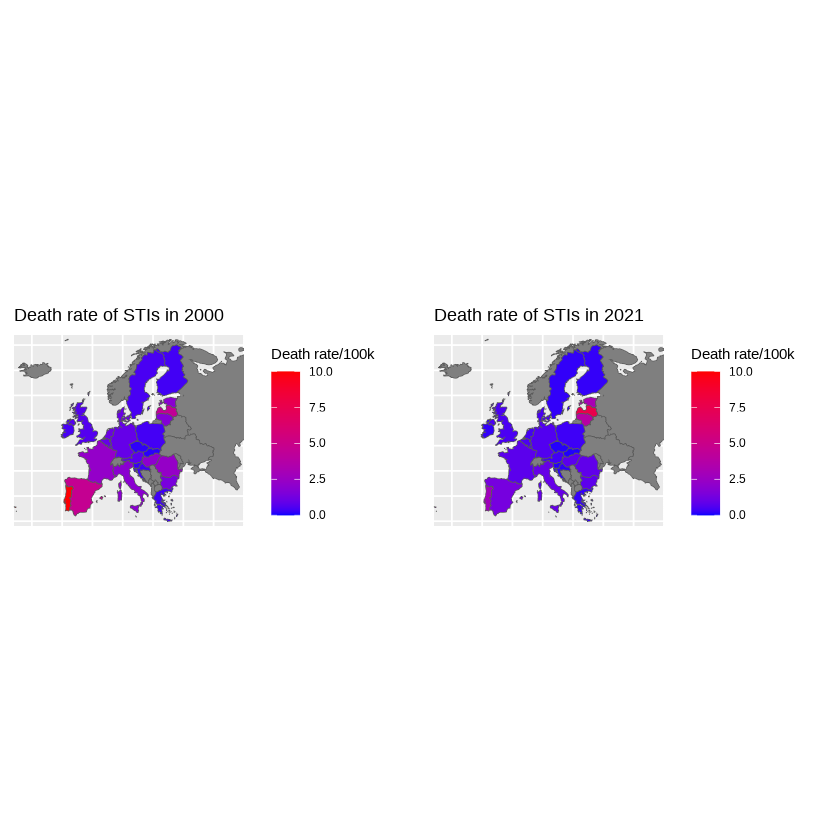

In [28]:
world <- ne_countries(scale = "medium", returnclass = "sf")
Europe <- world[which(world$continent == "Europe"),]

STI_D_00 <- STI %>%
  filter(measure == "Deaths" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == 2000) %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_D_00)[1] <- "name"

EuroSTI_D_00 <- merge(Europe,STI_D_00,by.y="name", all = TRUE)

p1 <- ggplot(EuroSTI_D_00) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "red", low = "blue", limits = c(0,10), name = "Death rate/100k")+
  labs(title= "Death rate of STIs in 2000")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank())


STI_D_21 <- STI %>%
  filter(measure == "Deaths" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == 2021) %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_D_21)[1] <- "name"

EuroSTI_D_21 <- merge(Europe,STI_D_21,by.y="name", all = TRUE)

p2 <- ggplot(EuroSTI_D_21) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "red", low = "blue", limits = c(0,10), name = "Death rate/100k")+
  labs(title= "Death rate of STIs in 2021")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank())

grid.arrange(p1,p2,nrow=1)

Prevalence map for Europe:

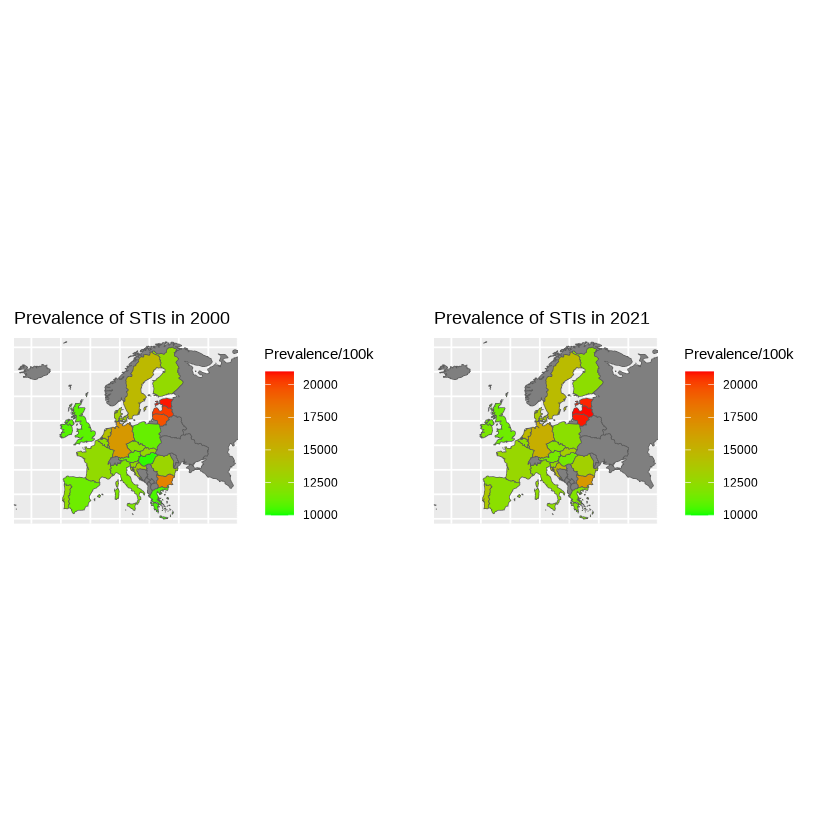

In [29]:
world <- ne_countries(scale = "medium", returnclass = "sf") #load worldmap data
Europe <- world[which(world$continent == "Europe"),] #isolate worldmap data to only europe

STI_P_00 <- STI %>% #DF with sums of all the prevalence rates for all the STIs by location for the year 2000
  filter(measure == "Prevalence" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == "2000") %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_P_00)[1] <- "name"

EuroSTI_P_00 <- merge(Europe,STI_P_00,by.y="name", all = TRUE)

p3 <- ggplot(EuroSTI_P_00) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "red", low = "green", limits = c(10000,21000), name = "Prevalence/100k")+
  labs(title= "Prevalence of STIs in 2000")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(), #remove long labels
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank()) #remove lat labels


STI_P_21 <- STI %>%
  filter(measure == "Prevalence" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == "2021") %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_P_21)[1] <- "name"

EuroSTI_P_21 <- merge(Europe,STI_P_21,by.y="name", all = TRUE)

p4 <- ggplot(EuroSTI_P_21) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "red", low = "green", limits = c(10000,21000), name = "Prevalence/100k")+
  labs(title= "Prevalence of STIs in 2021")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank())

grid.arrange(p3,p4,nrow=1)

Incidence map for Europe:

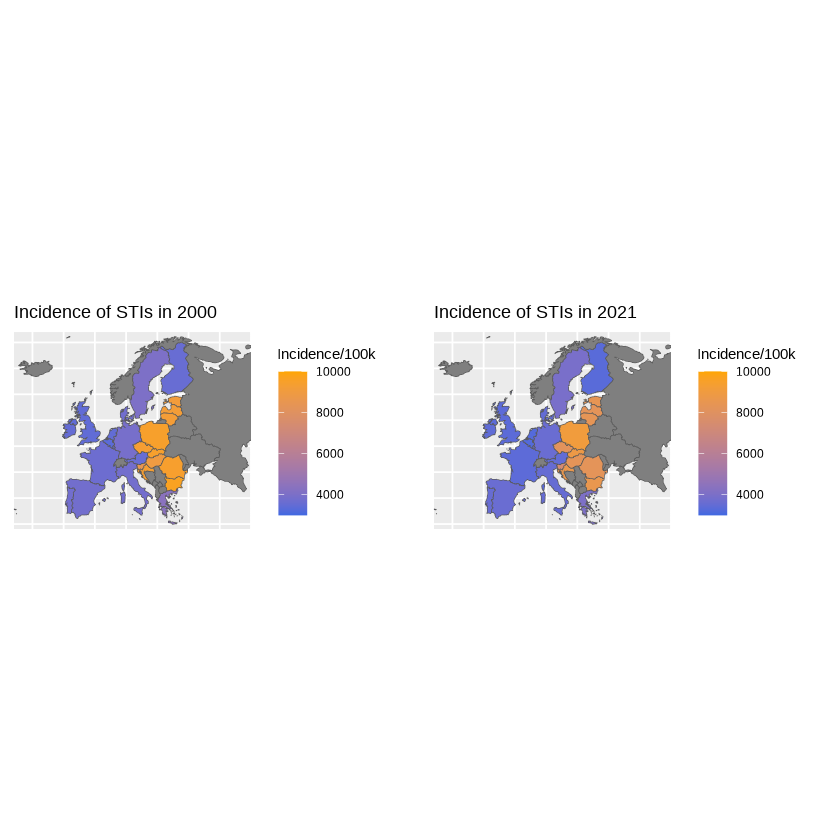

In [30]:
world <- ne_countries(scale = "medium", returnclass = "sf")
Europe <- world[which(world$continent == "Europe"),]

STI_I_00 <- STI %>%
  filter(measure == "Incidence" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == "2000") %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_I_00)[1] <- "name"

EuroSTI_I_00 <- merge(Europe,STI_I_00,by.y="name", all = TRUE)

p5 <- ggplot(EuroSTI_I_00) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "orange", low = "royalblue", limits = c(3000,10000), name = "Incidence/100k")+
  labs(title= "Incidence of STIs in 2000")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank())


STI_I_21 <- STI %>%
  filter(measure == "Incidence" & sex == "Both" & age == "All Ages" & metric == "Rate" & year == "2021") %>%
  group_by(location) %>%
  summarise(total= sum(val))
colnames(STI_I_21)[1] <- "name"

EuroSTI_I_21 <- merge(Europe,STI_I_21,by.y="name", all = TRUE)

p6 <- ggplot(EuroSTI_I_21) +
  geom_sf(aes(fill=total))+
  coord_sf(xlim = c(-26,50), ylim = c(34,72), expand = FALSE)+
  scale_fill_gradient(high = "orange", low = "royalblue", limits = c(3000,10000), name = "Incidence/100k")+
  labs(title= "Incidence of STIs in 2021")+
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank())

grid.arrange(p5,p6,nrow=1)

Combining all maps into a single plot:

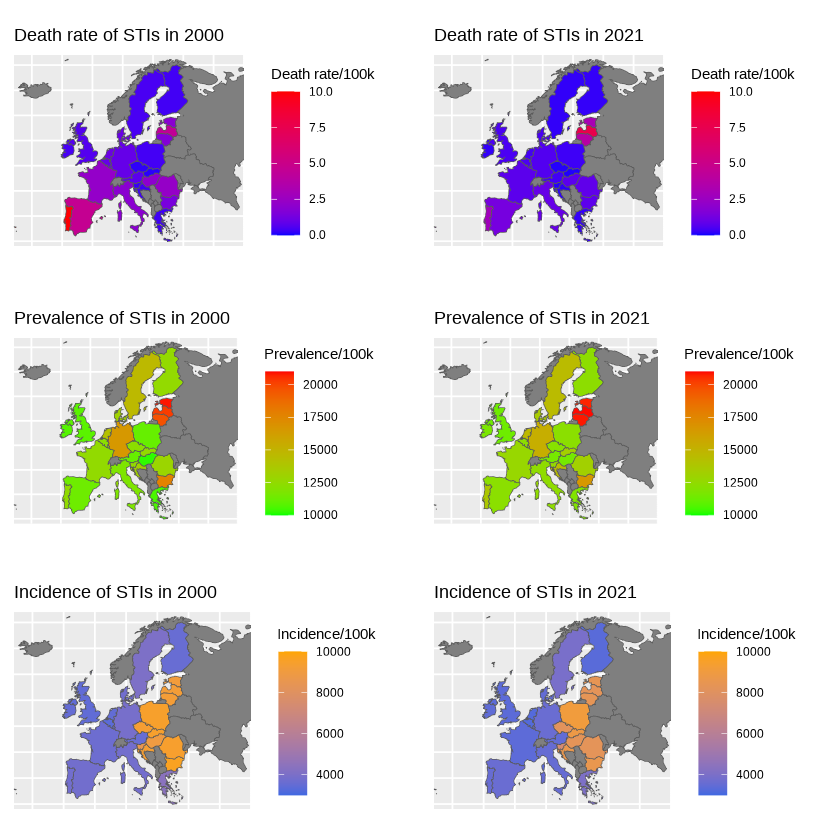

In [31]:
grid.arrange(p1,p2,p3,p4,p5,p6)

Death rate evolution through the years by cause


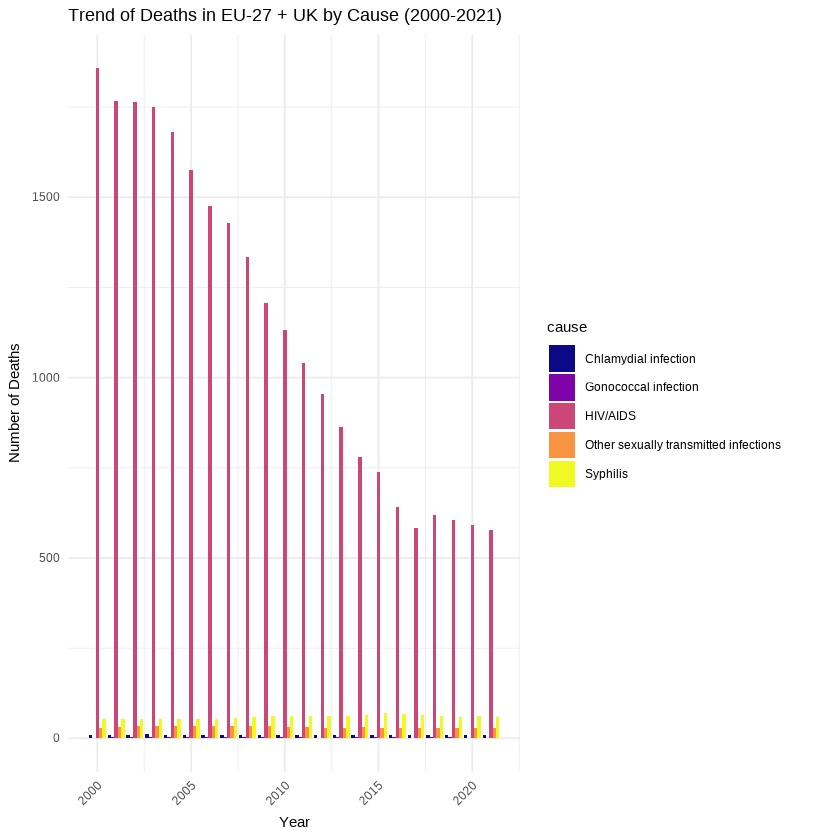

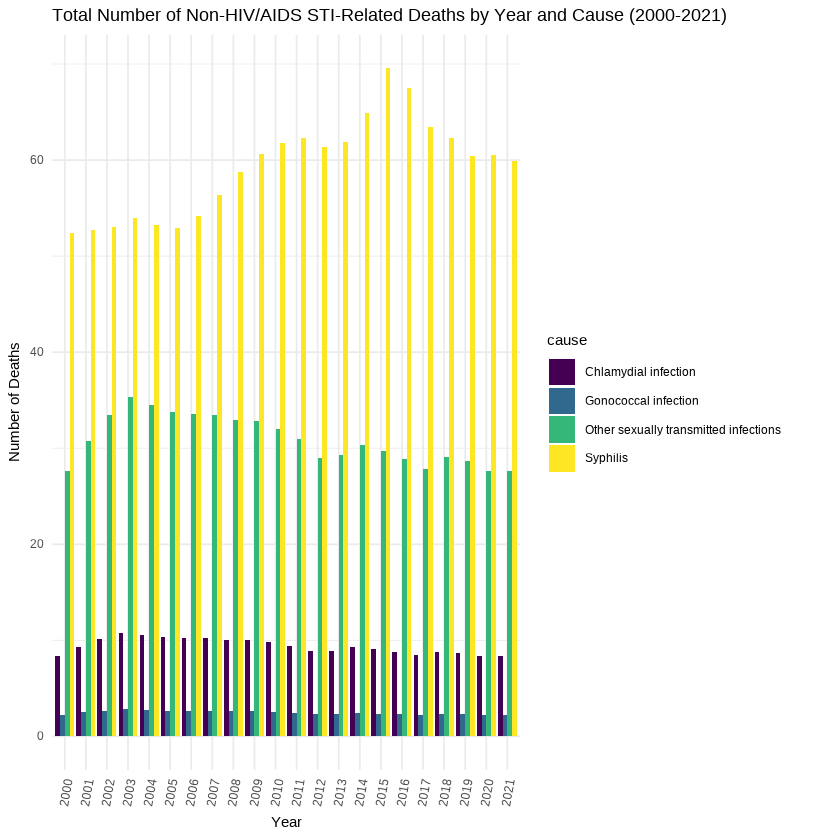

In [33]:
#c HIV only
ggplot(STI %>% 
         filter(measure == "Deaths" &
                  year >= 2000 & year <= 2021 &
                  metric == "Number" &
                  sex == "Both"), 
       aes(x = year, y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Trend of Deaths in EU-27 + UK by Cause (2000-2021)", x = "Year", y = "Number of Deaths") +
  scale_fill_viridis_d(option = "C") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


#c without HIV
ggplot(STI %>% 
         filter(measure == "Deaths" &
                  year >= 2000 & year <= 2021 &
                  metric == "Number" &
                  sex == "Both" &
                  cause != "HIV/AIDS"), 
       aes(x = factor(year), y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Total Number of Non-HIV/AIDS STI-Related Deaths by Year and Cause (2000-2021)", x = "Year", y = "Number of Deaths") +
  scale_fill_viridis_d(option = "D") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1))

Trend death rate for all STIs, per country, per year

`summarise()` has grouped output by 'location'. You can override using the
`.groups` argument.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`summarise()` has grouped output by 'cause'. You can override using the
`.groups` argument.


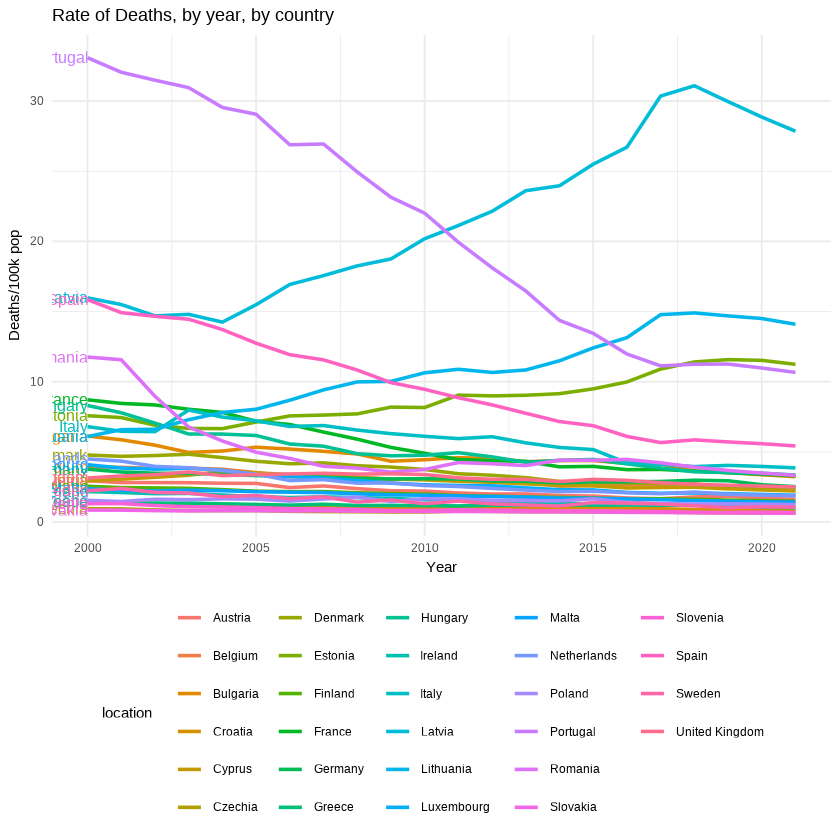

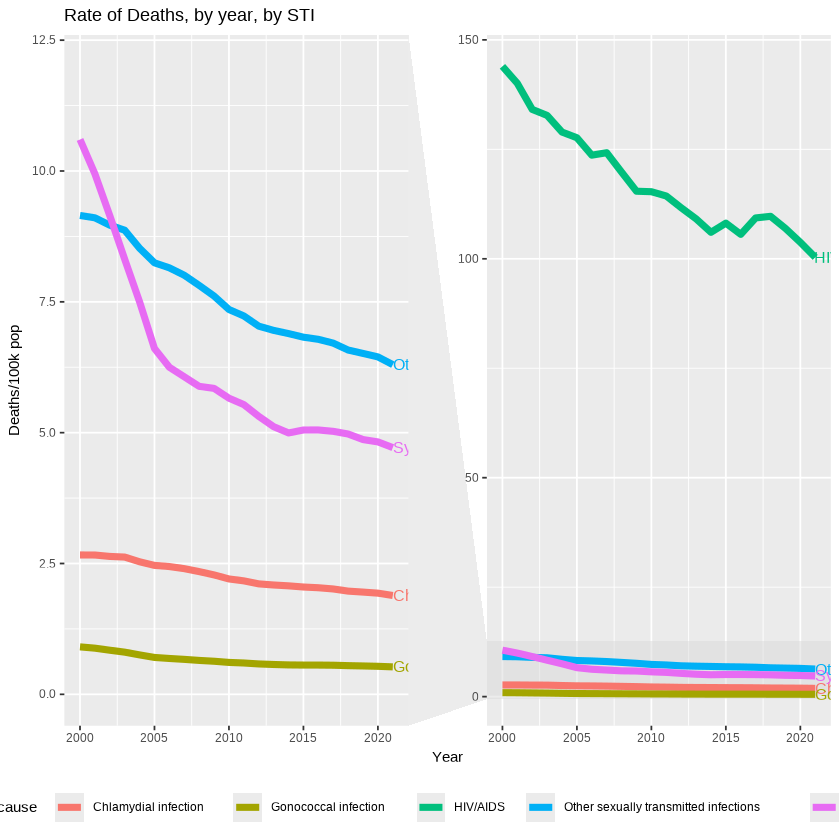

In [34]:
ggplot(STI %>%
         filter(measure == "Deaths" & sex == "Both" & metric == "Rate") %>%
         group_by(location, year) %>%
         summarise(totloc = sum(val)))+
  aes(x= year , y= totloc, colour= location)+
  geom_line(size = 1)+
  labs(x= "Year", y= "Deaths/100k pop", title= "Rate of Deaths, by year, by country")+
  theme_minimal()+
  theme(legend.position = "bottom")+
  geom_dl(aes(label= location), method = list("first.points"))

# Trend Death Rate all countries, per STI, per year -- INSET ZOOM
ggplot(STI %>%
         filter(measure == "Deaths" & sex == "Both" & metric == "Rate") %>%
         group_by(cause, year) %>%
         summarise(tcause = sum(val)))+
  aes(x= year , y= tcause, colour= cause)+
  geom_line(size = 2)+
  labs(x= "Year", y= "Deaths/100k pop", title= "Rate of Deaths, by year, by STI")+
  theme(legend.position = "bottom")+
  geom_dl(aes(label= cause), method = list("last.points"))+
  facet_zoom(ylim = c(0, 12), zoom.size = 1)

DALY rate evolution through the years by cause

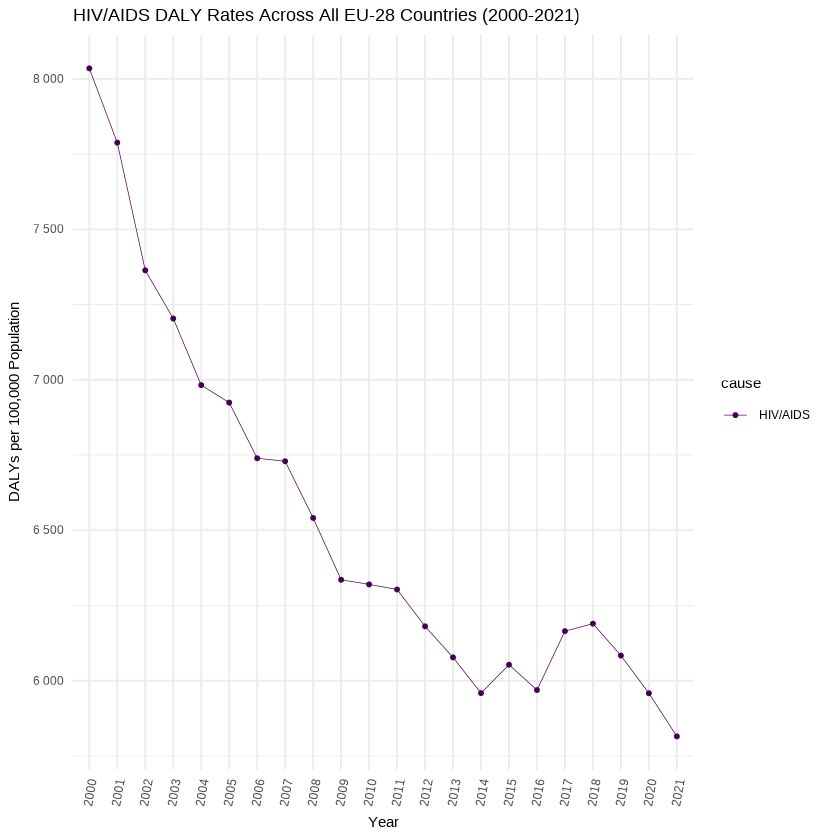

`summarise()` has grouped output by 'location'. You can override using the
`.groups` argument.


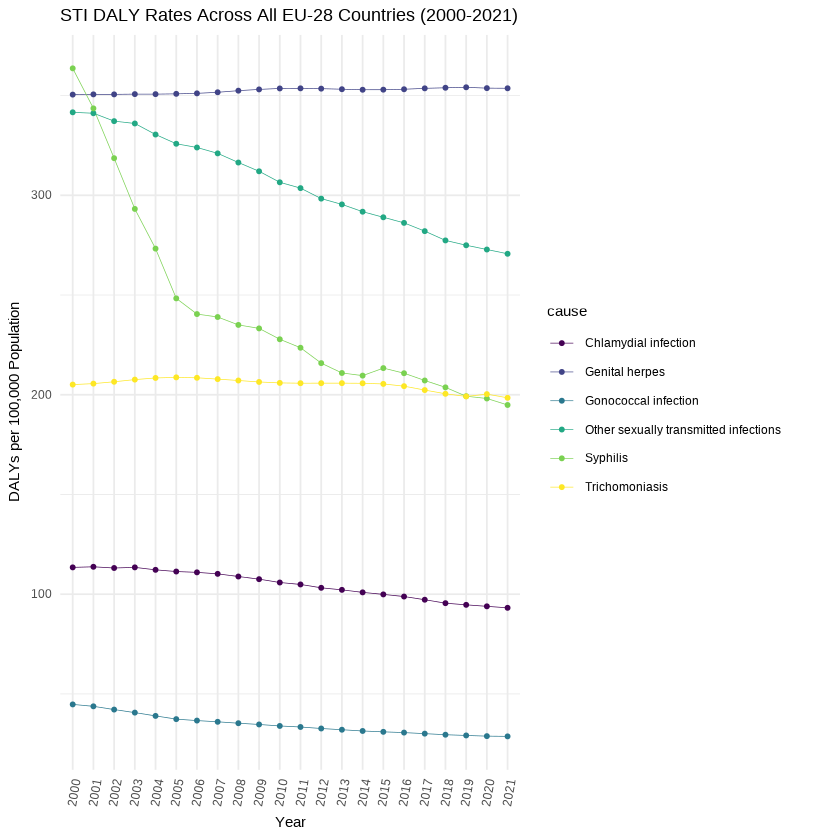

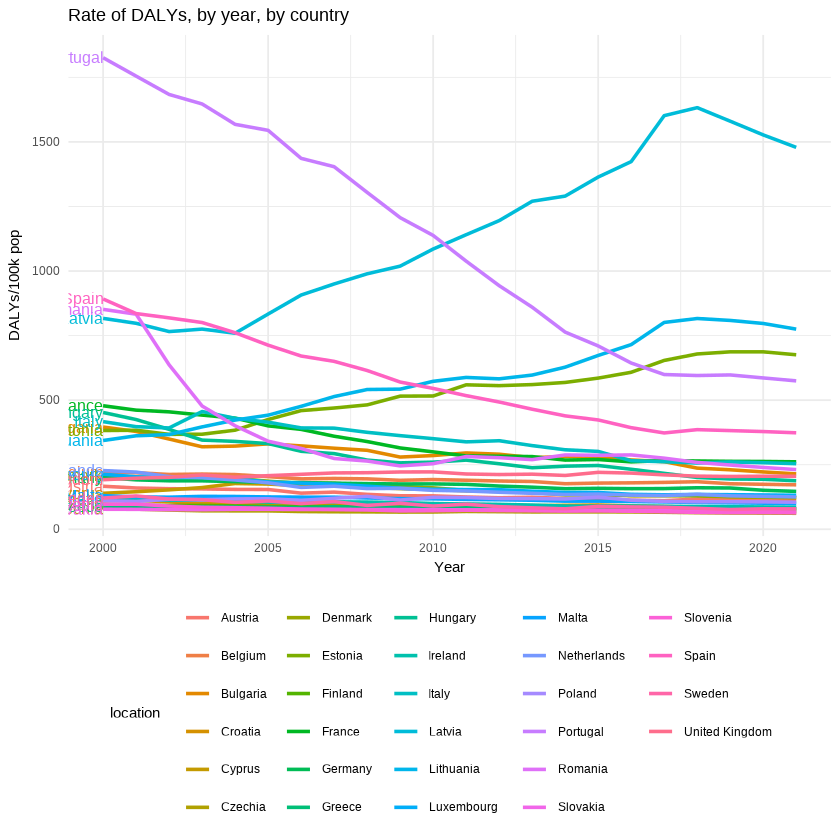

In [36]:
#c DALY Rate per year, HIV only
daly_rates_by_year <- STI %>%
  filter(measure == "DALYs (Disability-Adjusted Life Years)" &
           year >= 2000 & year <= 2021 & 
           metric == "Rate" & 
           sex == "Both" &
           cause == "HIV/AIDS") %>%
  group_by(year, cause) %>%
  summarise(daly_rate = sum(val, na.rm = TRUE), .groups = "drop")

ggplot(daly_rates_by_year, aes(x = factor(year), y = daly_rate, color = cause, group = cause)) +
  geom_line(linewidth = .2) + 
  geom_point(size = 1) +
  labs(title = "HIV/AIDS DALY Rates Across All EU-28 Countries (2000-2021)", 
       x = "Year", 
       y = "DALYs per 100,000 Population") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1)) +
  scale_color_viridis_d(option = "D")

#c DALY Rate per year, non-HIV only
daly_rates_by_year <- STI %>%
  filter(measure == "DALYs (Disability-Adjusted Life Years)" &
           year >= 2000 & year <= 2021 & 
           metric == "Rate" & 
           sex == "Both" &
           cause != "HIV/AIDS") %>%
  group_by(year, cause) %>%
  summarise(daly_rate = sum(val, na.rm = TRUE), .groups = "drop")

ggplot(daly_rates_by_year, aes(x = factor(year), y = daly_rate, color = cause, group = cause)) +
  geom_line(linewidth = 0.2) + 
  geom_point(size = 1) +
  labs(title = "STI DALY Rates Across All EU-28 Countries (2000-2021)", 
       x = "Year", 
       y = "DALYs per 100,000 Population") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1)) +
  scale_color_viridis_d(option = "D")

  # Trend DALYs all STIs, per country, per year
ggplot(STI %>%
         filter(measure == "DALYs (Disability-Adjusted Life Years)" & sex == "Both" & metric == "Rate") %>%
         group_by(location, year) %>%
         summarise(totloc = sum(val)))+
  aes(x= year , y= totloc, colour= location)+
  geom_line(size = 1)+
  labs(x= "Year", y= "DALYs/100k pop", title= "Rate of DALYs, by year, by country")+
  theme_minimal()+
  theme(legend.position = "bottom")+
  geom_dl(aes(label= location), method = list("first.points"))

Prevalence rate evolution through the years by cause

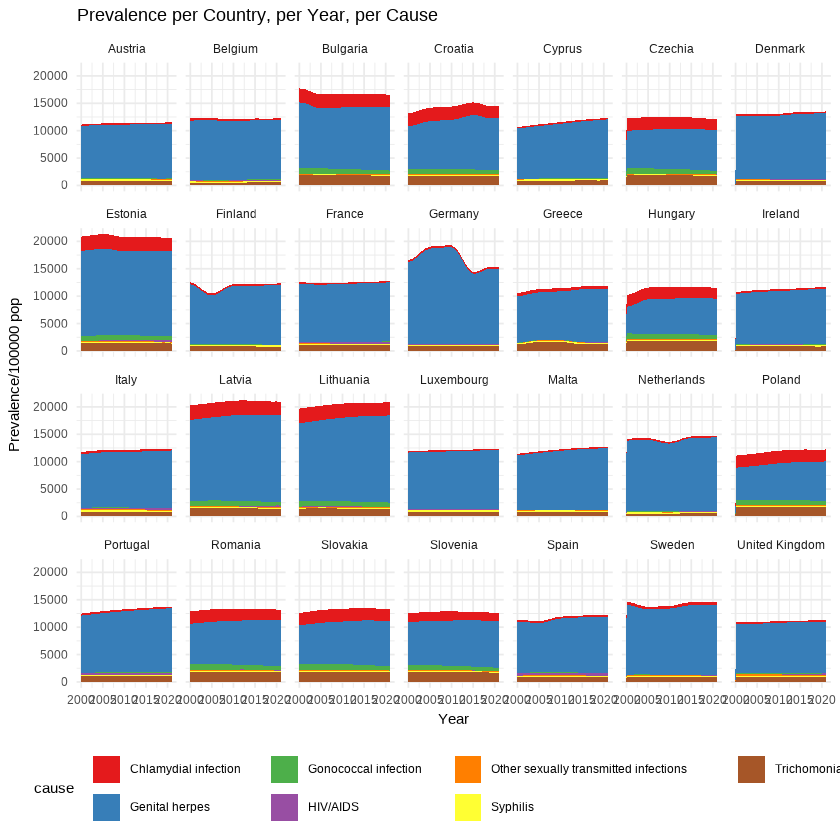

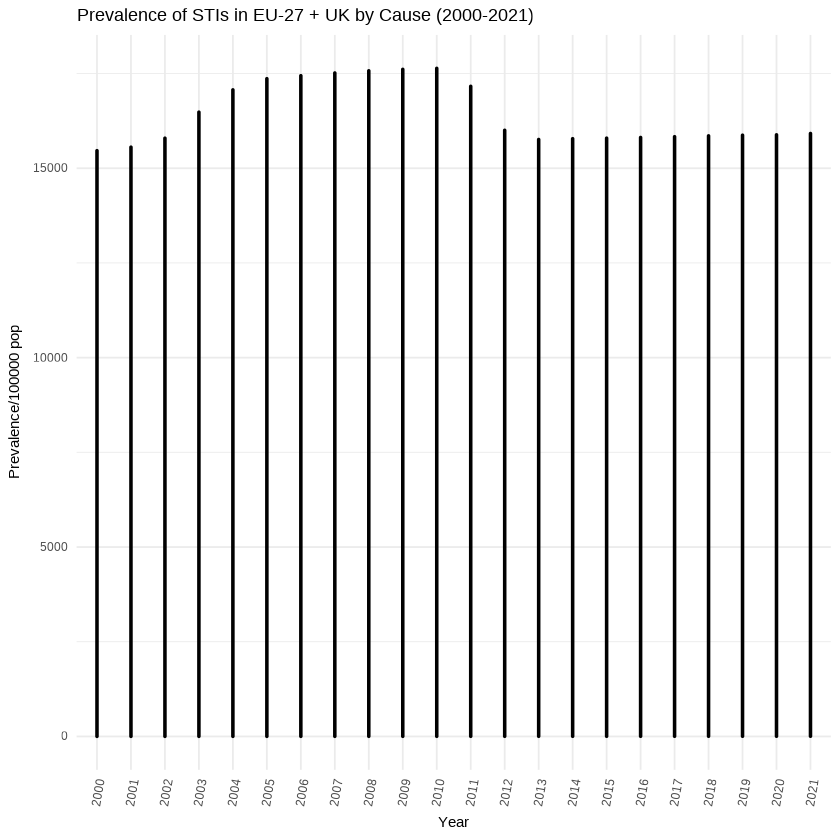

In [39]:
ggplot(STI %>% 
         filter(measure == "Prevalence" & metric == "Rate" & sex == "Both" & age == "All Ages"),
       aes(x=year, y=val, fill= cause)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "Prevalence/100000 pop", title= "Prevalence per Country, per Year, per Cause") +
  facet_wrap(vars(location), nrow = 4)+
  theme_minimal() +
  theme(legend.position = "bottom")

##

ggplot(STI %>% 
         filter(measure == "Prevalence" &
                  year >= 2000 & year <= 2021 &
                  metric == "Rate" &
                  sex == "Both" &
                  age == "All Ages"), 
       aes(x = factor(year), y = val)) +
  geom_line(size = 1) +
  labs(title = "Prevalence of STIs in EU-27 + UK by Cause (2000-2021)", x = "Year", y = "Prevalence/100000 pop") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1))

`summarise()` has grouped output by 'location'. You can override using the
`.groups` argument.


<ScaleContinuousPosition>
 Range:  
 Limits:    0 --    1

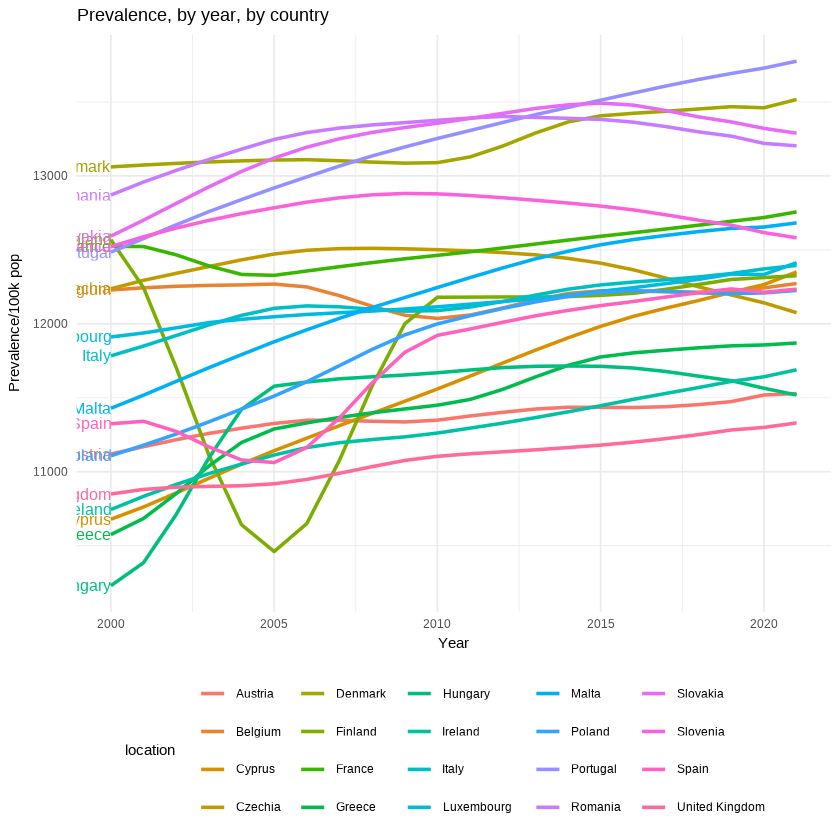

In [40]:
# Trend Prevalence Rate all STIs, per country, per year
ggplot(STI %>%
         filter(measure == "Prevalence" & 
                  sex == "Both" & 
                  metric == "Rate" & 
                  age =="All Ages" &
                  location != "Estonia" & location != "Latvia" & location != "Lithuania" &
                  location != "Bulgaria" & location != "Germany" & location != "Sweden" &
                  location != "Netherlands" & location != "Croatia") %>%
         group_by(location, year) %>%
         summarise(totloc = sum(val)))+
  aes(x= year , y= totloc, colour = location)+
  geom_line(size = 1)+
  labs(x= "Year", y= "Prevalence/100k pop", title= "Prevalence, by year, by country")+
  theme_minimal()+
  theme(legend.position = "bottom")+
  geom_dl(aes(label= location), method = list("first.points"))
  scale_y_continuous(labels = label_number(accuracy = 100))


Incidence rate evolution through the years by cause

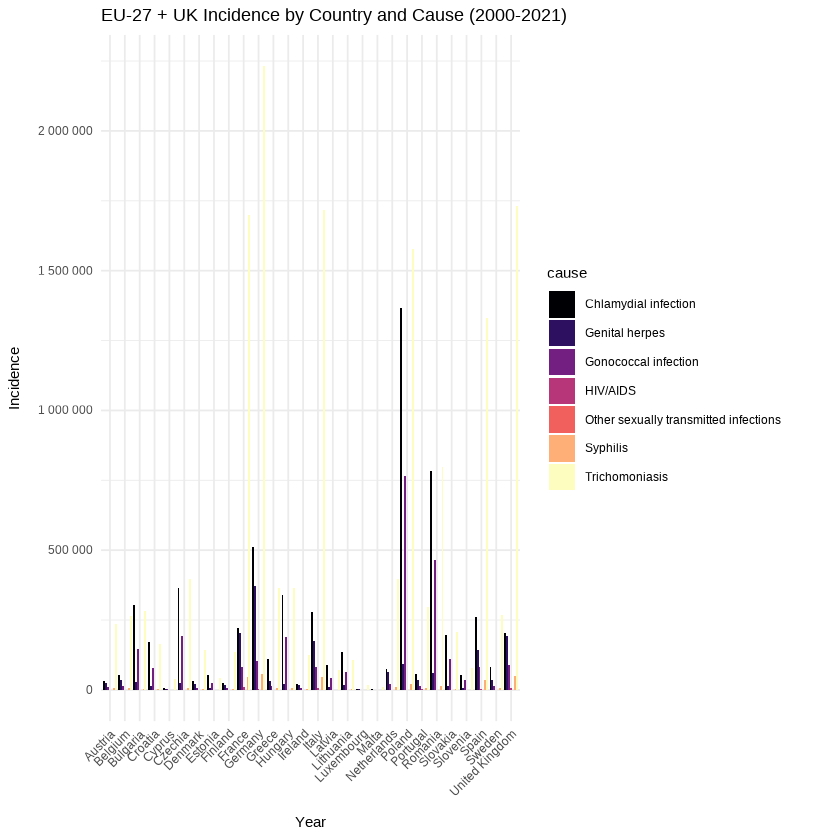

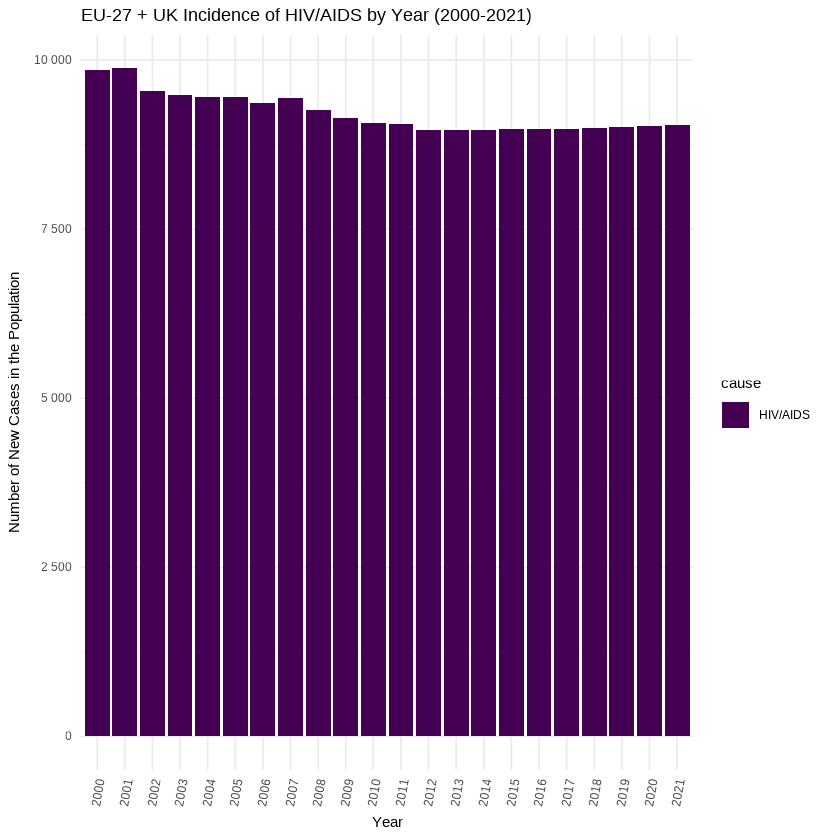

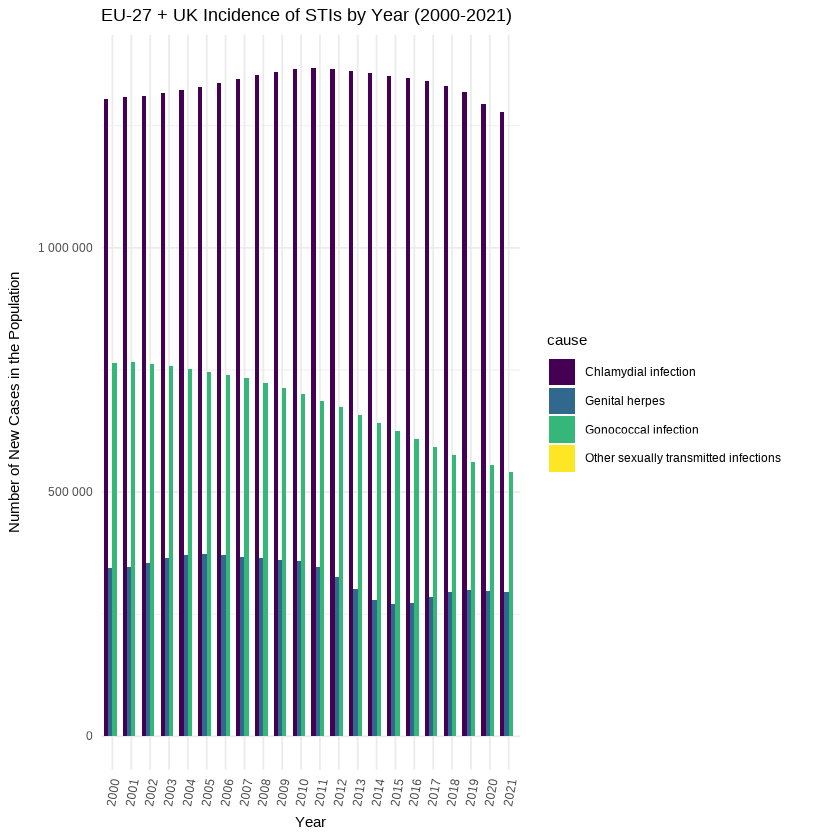

`summarise()` has grouped output by 'location'. You can override using the
`.groups` argument.


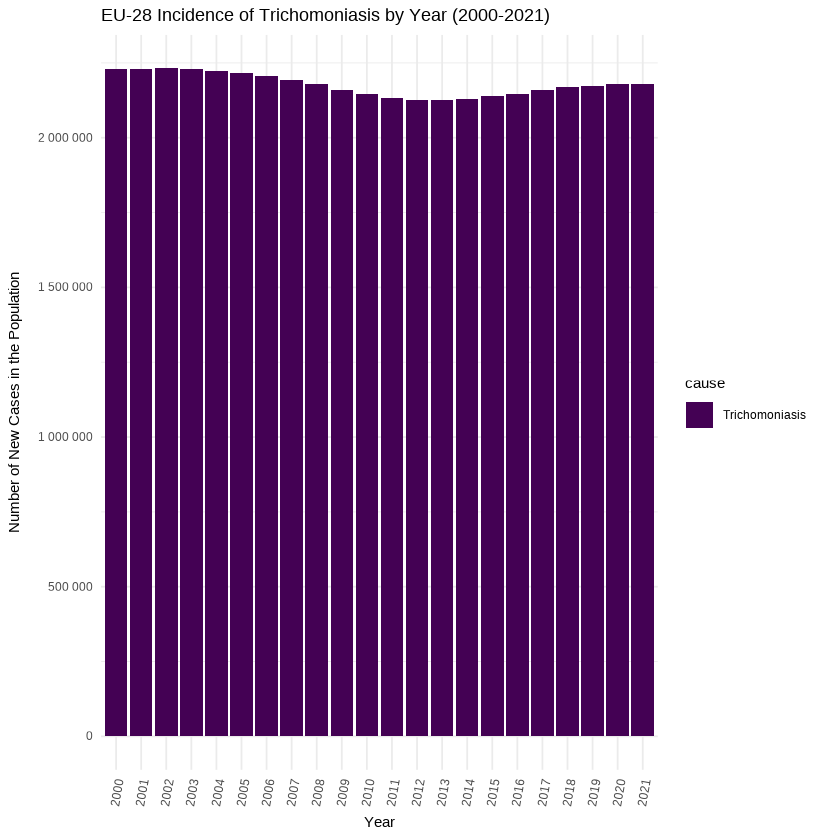

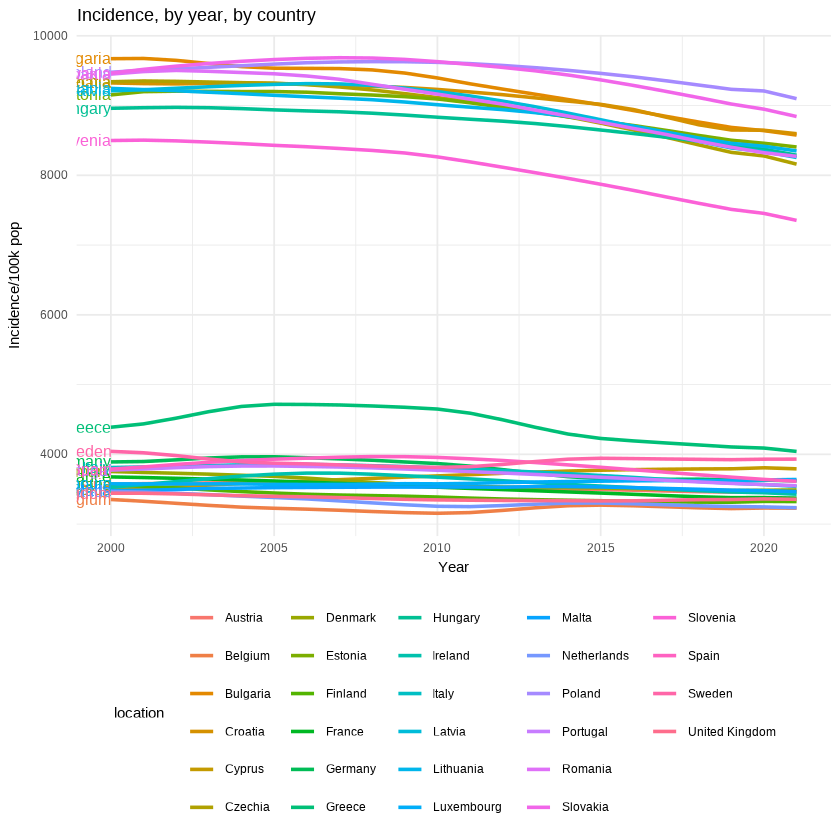

In [43]:
#c
ggplot(STI %>% 
         filter(measure == "Incidence" &
                  year >= 2000 & year <= 2021 &
                  metric == "Number" &
                  sex == "Both"), 
       aes(x = location, y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "EU-27 + UK Incidence by Country and Cause (2000-2021)", x = "Year", y = "Incidence") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  scale_fill_viridis_d(option = "A") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#c only HIV
ggplot(STI %>% 
         filter(measure == "Incidence" &
                  metric == "Number" &
                  sex == "Both" &
                  cause == "HIV/AIDS"), 
       aes(x = factor(year), y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "EU-27 + UK Incidence of HIV/AIDS by Year (2000-2021)", x = "Year", y = "Number of New Cases in the Population") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  scale_fill_viridis_d(option = "D") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1))

#c only CT NG HSV
ggplot(STI %>% 
         filter(measure == "Incidence" &
                  year >= 2000 & year <= 2021 &
                  metric == "Number" &
                  sex == "Both" &
                  cause != "HIV/AIDS" & cause != "Other STIs" & cause != "Trichomoniasis" & cause != "Syphilis"), 
       aes(x = factor(year), y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "EU-27 + UK Incidence of STIs by Year (2000-2021)", x = "Year", y = "Number of New Cases in the Population") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  scale_fill_viridis_d(option = "D") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1))

#c TV
ggplot(STI %>% 
         filter(measure == "Incidence" &
                  year >= 2000 & year <= 2021 &
                  metric == "Number" &
                  sex == "Both" &
                  cause == "Trichomoniasis"), 
       aes(x = factor(year), y = val, fill = cause)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "EU-28 Incidence of Trichomoniasis by Year (2000-2021)", x = "Year", y = "Number of New Cases in the Population") +
  scale_y_continuous(labels = label_number(accuracy = 1)) +
  scale_fill_viridis_d(option = "D") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 80, hjust = 1))


# Trend Incidence Rate all STIs, per country, per year
ggplot(STI %>%
         filter(measure == "Incidence" & sex == "Both" & age == "All Ages" & metric == "Rate") %>%
         group_by(location, year) %>%
         summarise(totloc = sum(val)))+
  aes(x= year , y= totloc, colour= location)+
  geom_line(size = 1)+
  labs(x= "Year", y= "Incidence/100k pop", title= "Incidence, by year, by country")+
  theme_minimal()+
  theme(legend.position = "bottom")+
  geom_dl(aes(label= location), method = list("first.points"))

Death rates of HIV in both sexes

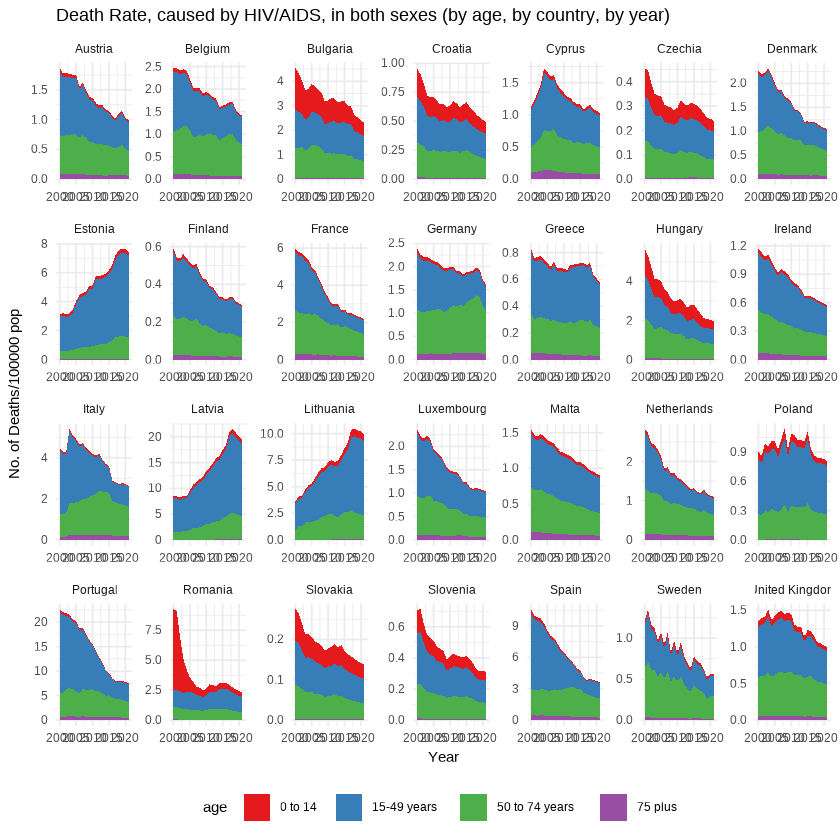

In [44]:
# Death Rate caused by HIV in both sexes (by age, country, year)
ggplot(STI %>% 
         filter(measure == "Deaths" & cause == "HIV/AIDS" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
       aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "No. of Deaths/100000 pop", title= "Death Rate, caused by HIV/AIDS, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

Death rates of syphilis in both sexes

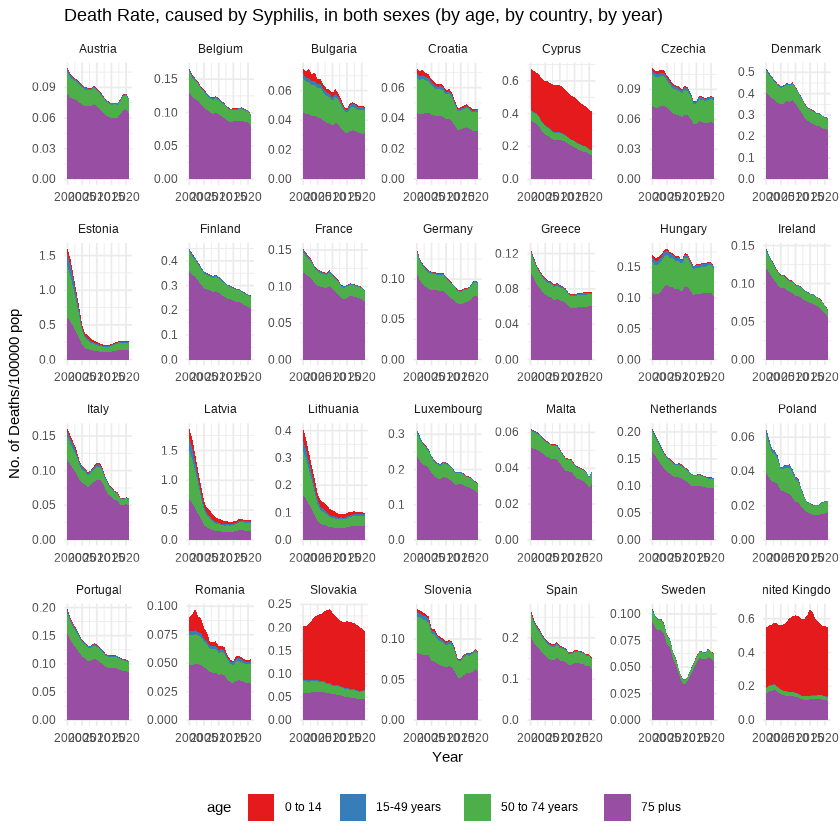

In [45]:
ggplot(STI %>% 
         filter(measure == "Deaths" & cause == "Syphilis" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
       aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "No. of Deaths/100000 pop", title= "Death Rate, caused by Syphilis, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

DALYs for HIV in both sexes

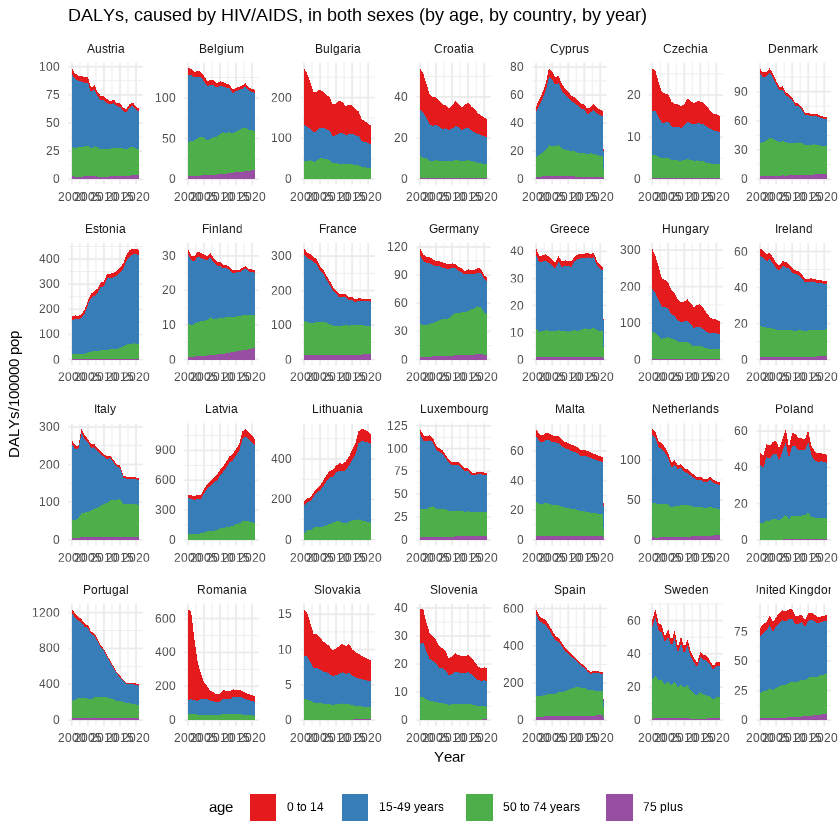

In [46]:
ggplot(STI %>% 
         filter(measure == "DALYs (Disability-Adjusted Life Years)" & cause == "HIV/AIDS" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
       aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "DALYs/100000 pop", title= "DALYs, caused by HIV/AIDS, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

DALYs for syphilis in both sexes

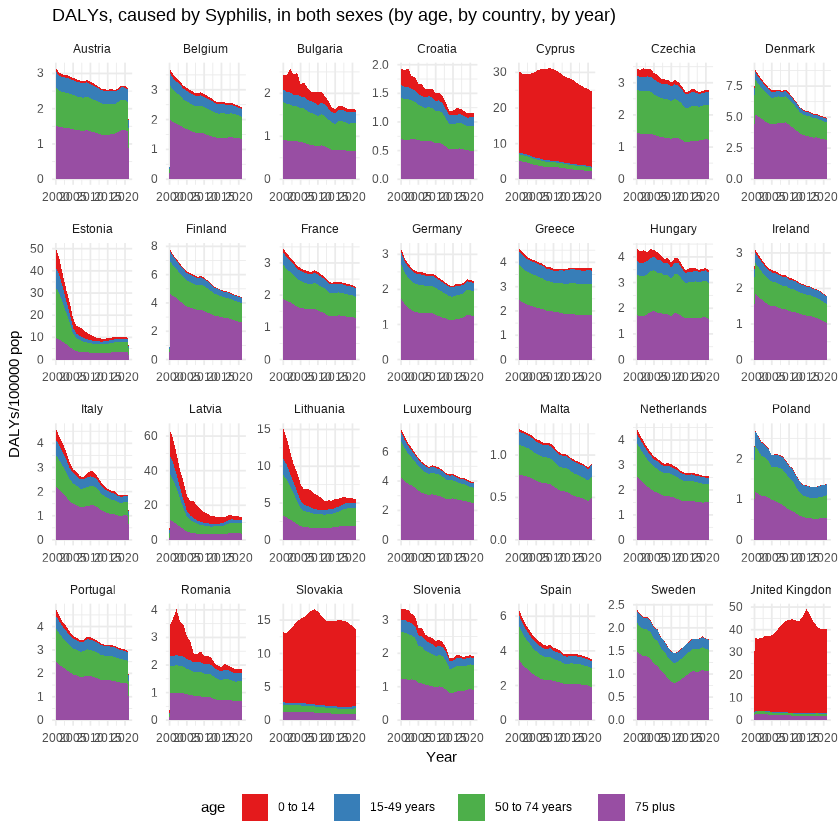

In [47]:
ggplot(STI %>% 
         filter(measure == "DALYs (Disability-Adjusted Life Years)" & cause == "Syphilis" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
       aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "DALYs/100000 pop", title= "DALYs, caused by Syphilis, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

Prevalence of genital herpes in both sexes

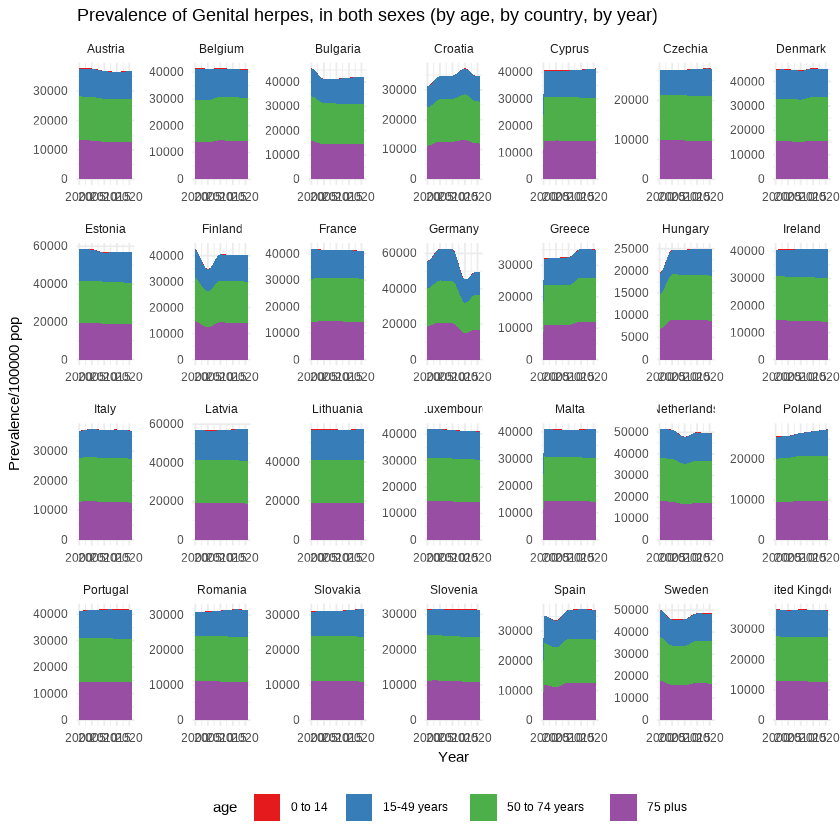

In [48]:
ggplot(STI %>%
         filter(measure == "Prevalence" & cause == "Genital herpes" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
       aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "Prevalence/100000 pop", title= "Prevalence of Genital herpes, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

Prevalence of Chlamydial Infection in both sexes

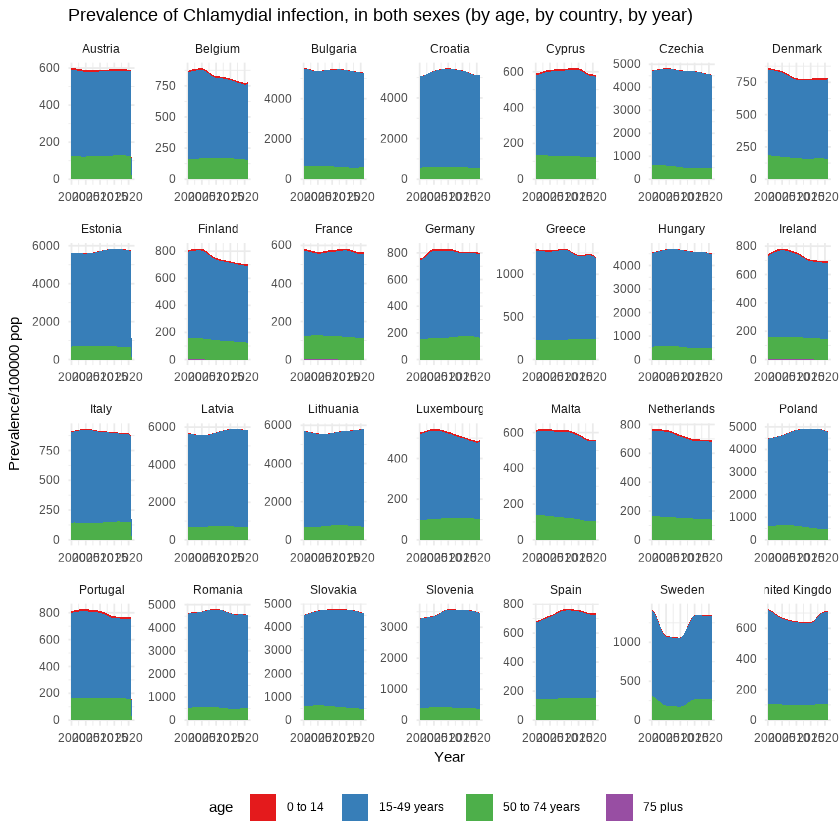

In [49]:
ggplot(STI %>%
        filter(measure == "Prevalence" & cause == "Chlamydial infection" & metric == "Rate" & sex == "Both" & age!= "All Ages"),
      aes(x=year, y=val, fill= age)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "Prevalence/100000 pop", title= "Prevalence of Chlamydial infection, in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

Prevalence of Chlamydial Infection in all ages

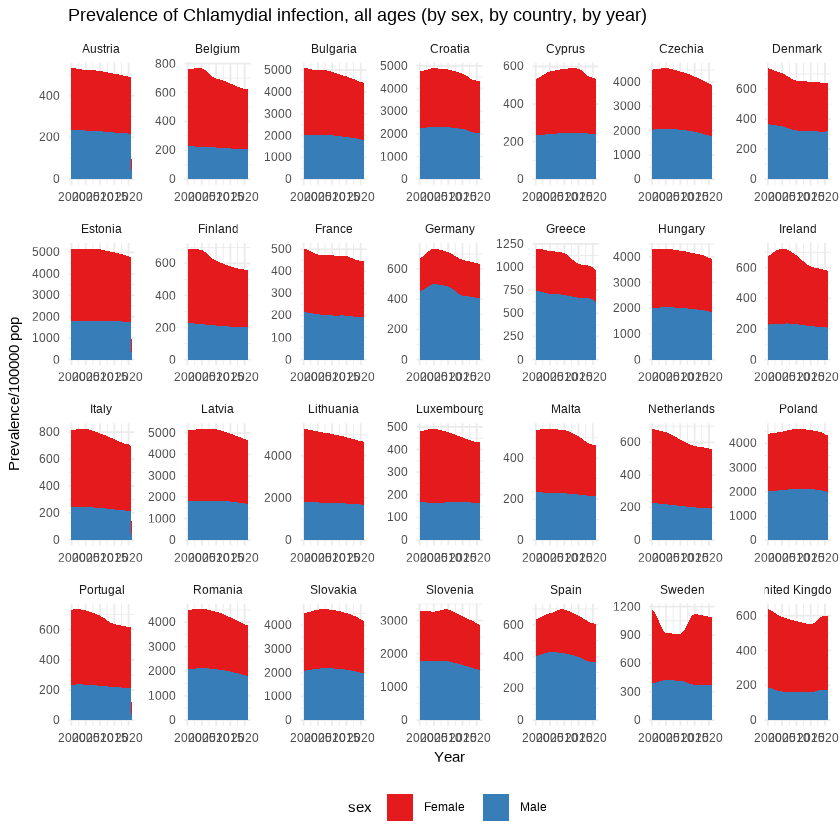

In [50]:
ggplot(STI %>%
         filter(measure == "Prevalence" & cause == "Chlamydial infection" & metric == "Rate" & sex != "Both" & age== "All Ages"),
       aes(x=year, y=val, fill= sex)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "Prevalence/100000 pop", title= "Prevalence of Chlamydial infection, all ages (by sex, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")

DALYs of HIV in all ages

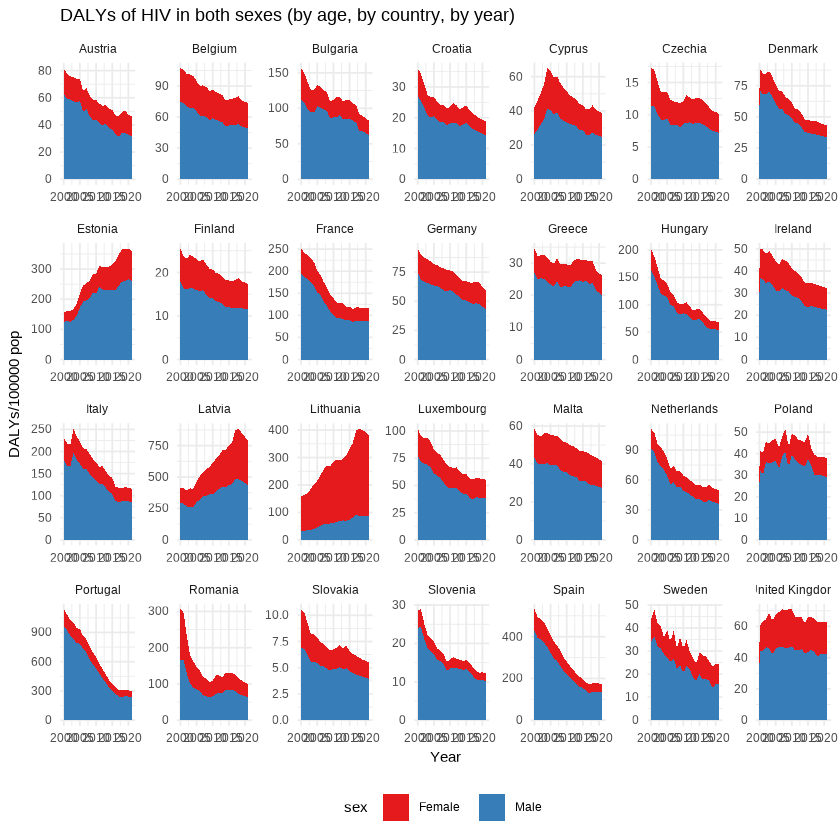

In [51]:
ggplot(STI %>%
        filter(measure == "DALYs (Disability-Adjusted Life Years)" & cause == "HIV/AIDS" & metric == "Rate" & sex != "Both" & age == "All Ages"),
      aes(x=year, y=val, fill= sex)) +
  geom_area() +
  # scale_color_brewer(palette = "Spectral")+
  scale_fill_brewer(palette = "Set1") +
  labs(x= "Year", y= "DALYs/100000 pop", title= "DALYs of HIV in both sexes (by age, by country, by year)") +
  facet_wrap(vars(location), nrow = 4, scales = "free")+
  theme_minimal() +
  theme(legend.position = "bottom")